## Artificial Intelligence Guided By The Laws Of Physics
#### **Physical Informed Neural Network (PINN)**
#### Réseaux de neurones informés par la physique
### **Pr. Mohamed YOUSSF**

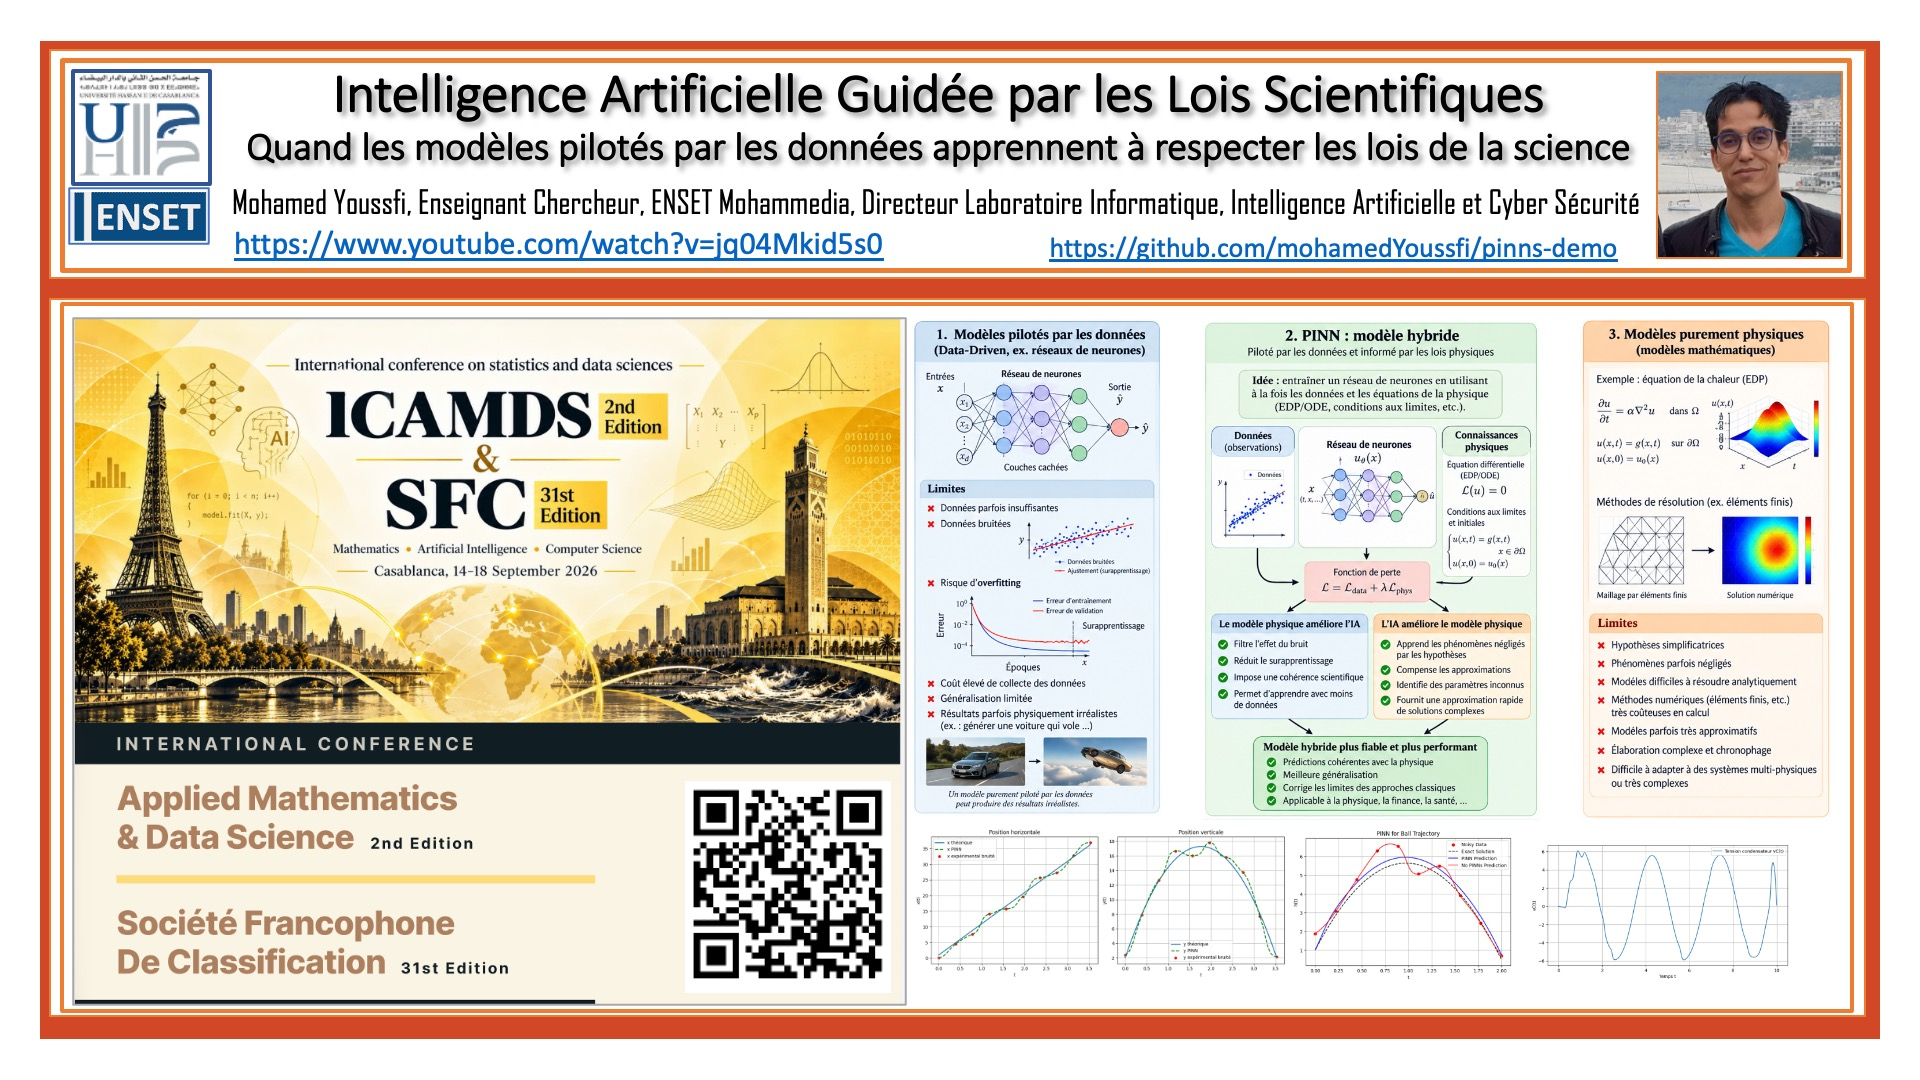

### Physics Driven Model

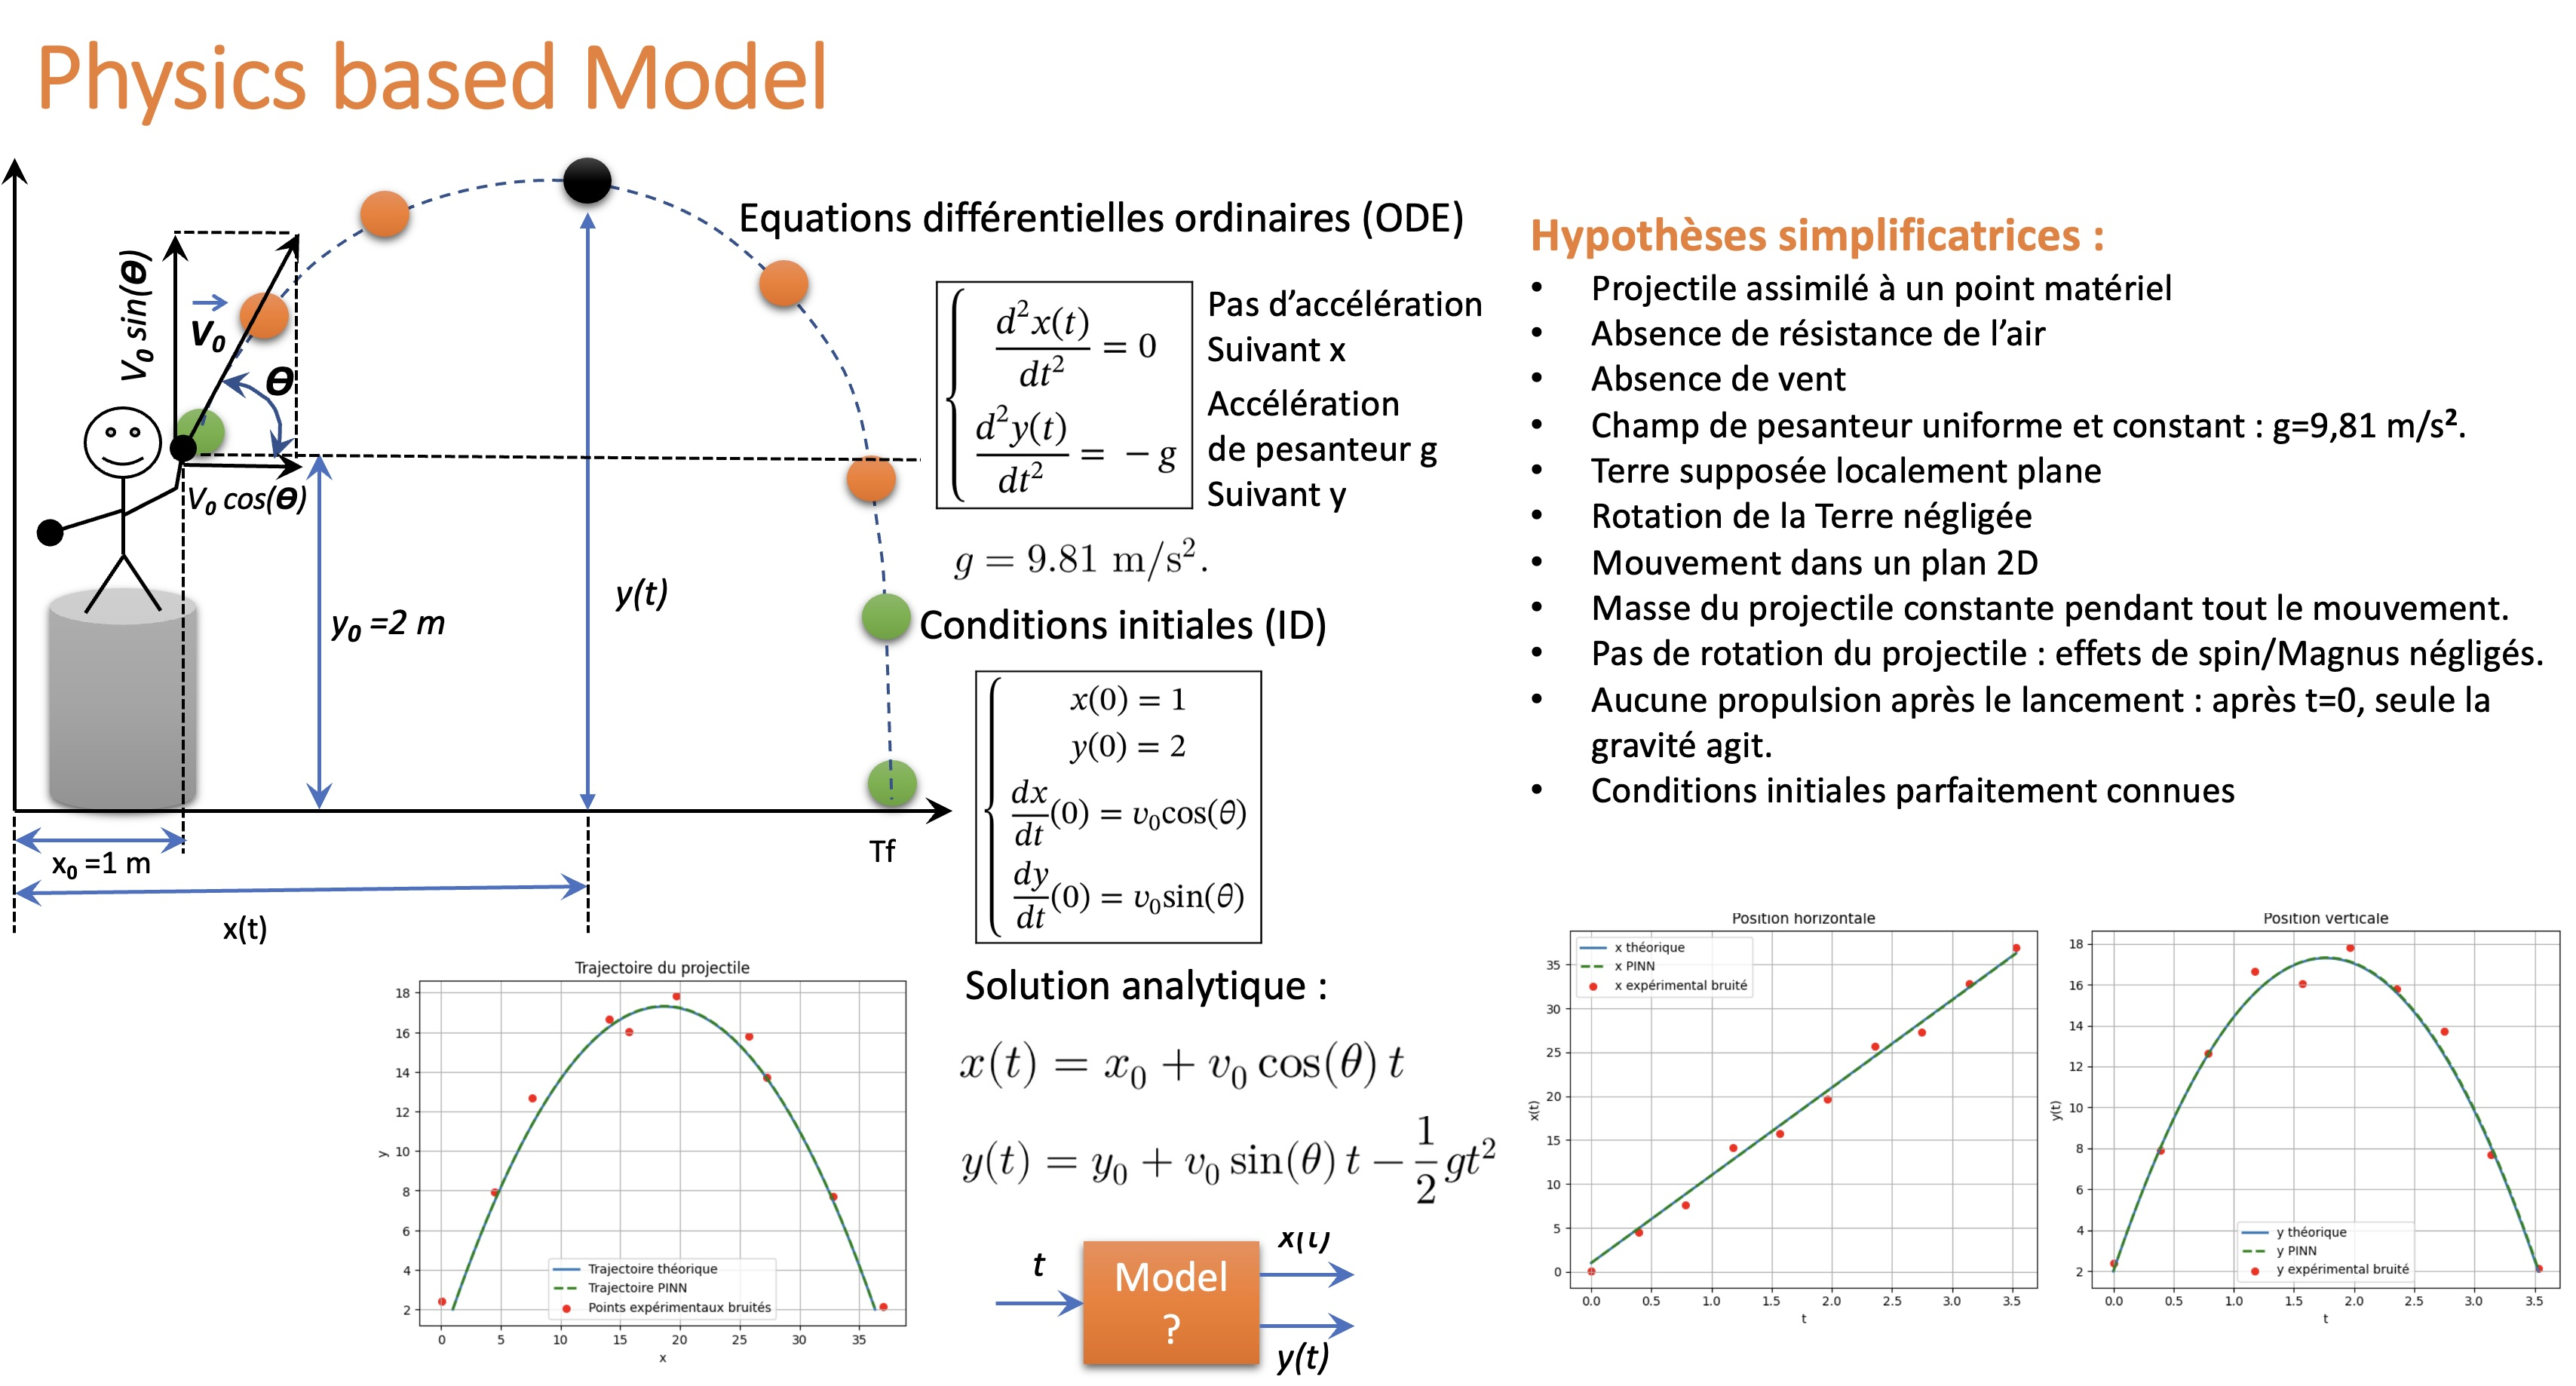

Temps de vol théorique : 3.5311943069701877


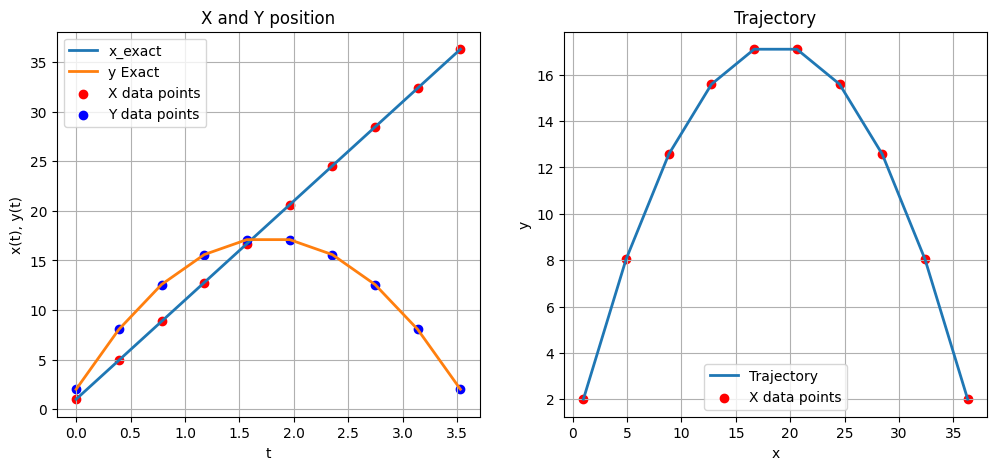

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math
import pandas as pd
torch.manual_seed(42)
# Paramètres physiques
g = 9.81
# Conditions initiales
x0 = 1.0
y0 = 2.0

teta = math.pi/3
v0 = 20 # m/s
vx0 = v0*math.cos(teta) 
vy0 = v0*math.sin(teta) 

def physics_model(t):
    # Solution théorique exacte
    x_exact = x0 + vx0 * t
    y_exact = y0 + vy0 * t - 0.5 * g * t ** 2
    return x_exact, y_exact
# ==============================
# 6. Données expérimentales simulées
# ==============================
# Temps de vol théorique pour y = 2
T_final = 2 * vy0 / g
print("Temps de vol théorique :", T_final)
N_data = 10
t_test = torch.linspace(0, T_final, N_data).view(-1, 1)

x, y = physics_model(t_test)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_test, x, label="x_exact", linewidth=2)
plt.plot(t_test, y, label="y Exact", linewidth=2)
plt.scatter(t_test,x,color="red",label="X data points")
plt.scatter(t_test,y,color="blue",label="Y data points")
plt.xlabel("t")
plt.ylabel("x(t), y(t)")
plt.title("X and Y position")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(x, y, label="Trajectory", linewidth=2)
plt.scatter(x,y,color="red",label="X data points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory")
plt.legend()
plt.grid()

In [2]:
noise_level = 0.9
t_data = torch.linspace(0, T_final, N_data).view(-1, 1)

# Solution théorique aux temps expérimentaux
x_data_exact = x0 + vx0 * t_data
y_data_exact = y0 + vy0 * t_data - 0.5 * g * t_data ** 2

# Bruit gaussien
noise_x = noise_level * torch.randn_like(x_data_exact)
noise_y = noise_level * torch.randn_like(y_data_exact)

# Données expérimentales bruitées
x_data_exp = x_data_exact + noise_x
y_data_exp = y_data_exact + noise_y

# Regrouper en un tenseur de shape : [N_data, 2]
data_exp = torch.cat([x_data_exp, y_data_exp], dim=1)
pd.DataFrame(torch.cat((t_data, data_exp), dim=1), columns=['time','x','y'])

,time,x,y
0,0.000000,1.303021,2.481414
1,0.392355,5.039478,8.769120
2,0.784710,9.058114,13.570485
3,1.177065,12.977947,14.070755
4,1.569420,15.683626,16.211685
5,1.961775,20.450050,17.963924
6,2.354130,26.528677,16.781498
7,2.746484,27.890646,13.306699
8,3.138839,32.803886,7.351448
9,3.531194,36.552559,1.324444


### Data Driven Model

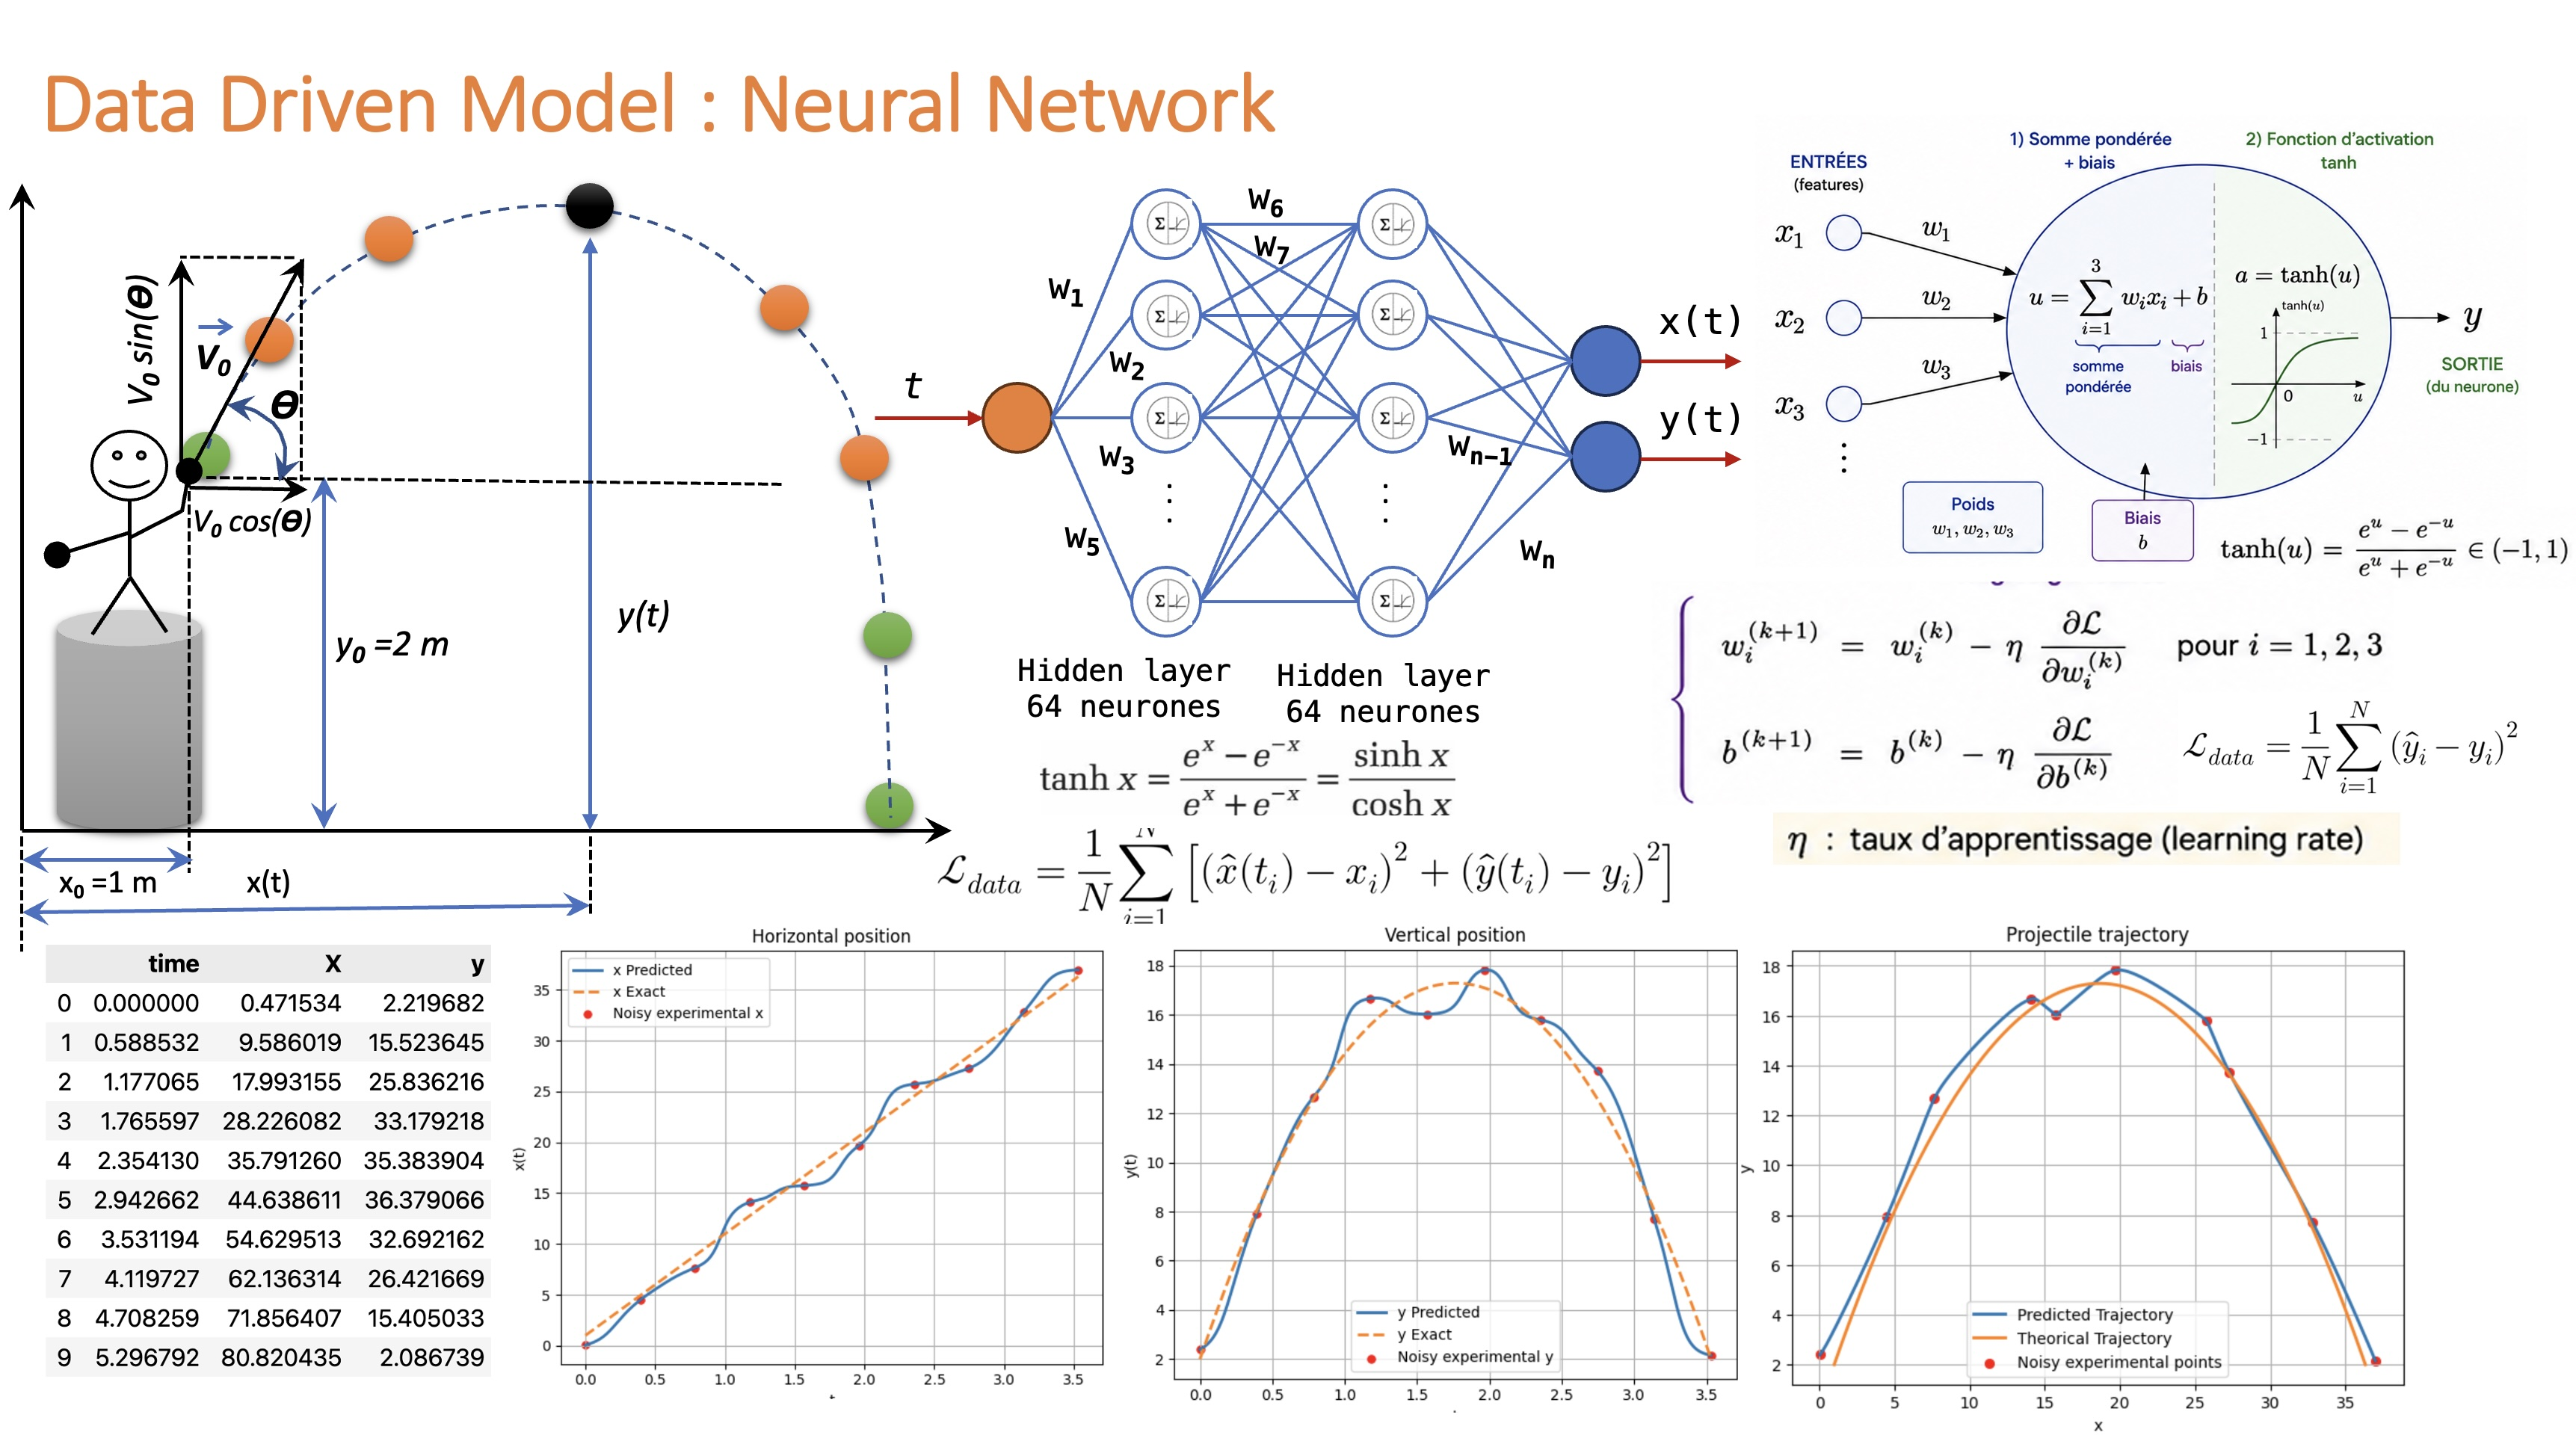

Epoch [1000/8000] Loss: 5.292188 | 
Epoch [2000/8000] Loss: 0.374746 | 
Epoch [3000/8000] Loss: 0.074300 | 
Epoch [4000/8000] Loss: 0.024115 | 
Epoch [5000/8000] Loss: 0.008057 | 
Epoch [6000/8000] Loss: 0.001878 | 
Epoch [7000/8000] Loss: 0.000201 | 
Epoch [8000/8000] Loss: 0.000008 | 
torch.Size([10, 1]) torch.Size([10, 2])


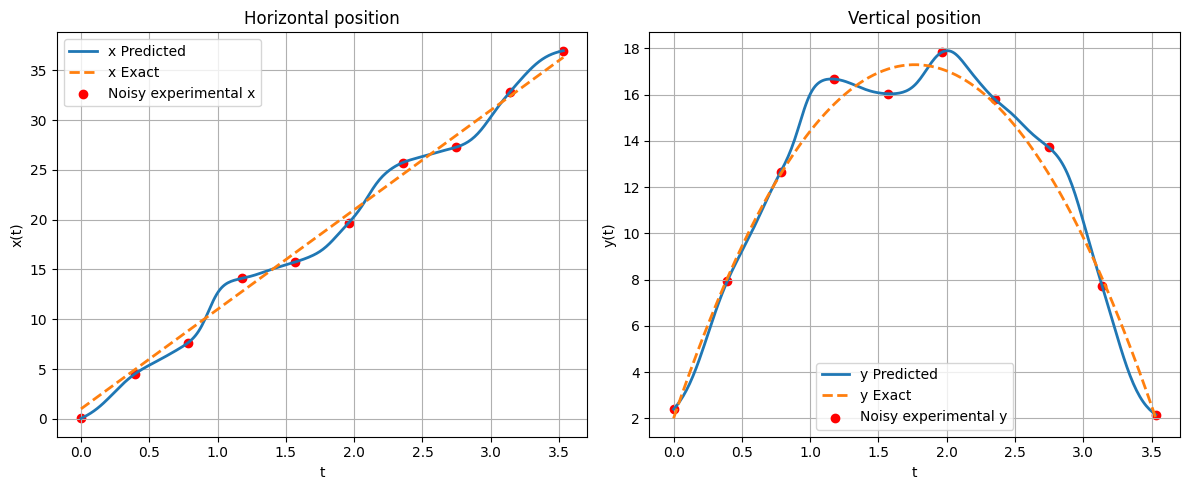

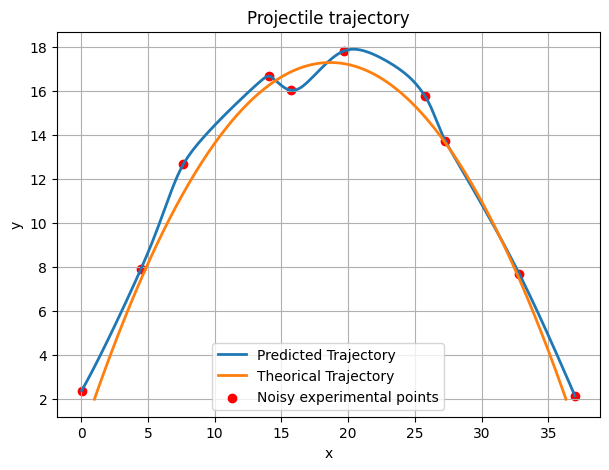

R2_score = 1.00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math
from torcheval.metrics import R2Score
torch.manual_seed(42)
time = torch.tensor([
        [0.0000],
        [0.3924],
        [0.7847],
        [1.1771],
        [1.5694],
        [1.9618],
        [2.3541],
        [2.7465],
        [3.1388],
        [3.5312]])
position = torch.tensor([
        [ 0.0488,  2.3954],
        [ 4.4880,  7.9184],
        [ 7.6540, 12.6630],
        [14.1065, 16.6683],
        [15.7570, 16.0307],
        [19.7154, 17.8220],
        [25.7322, 15.7916],
        [27.2776, 13.7168],
        [32.8069,  7.7049],
        [36.9753,  2.1562]])


# ==============================
# 1. Configuration
# ==============================

#time = t_data
#position = data_exp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

data_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 2)  # sortie : [x(t), y(t)]
)

optimizer = optim.Adam(data_model.parameters(), lr=0.001)
critetion = nn.MSELoss() 

# ==============================
# 8. Entraînement
# ==============================

epochs = 8000

for epoch in range(epochs):

    data_model.train()
    pred = data_model(time)

    x_pred = pred[:, 0:1]
    y_pred = pred[:, 1:2]

    #loss_data = torch.mean((pred - position) ** 2)
    loss_data = critetion(pred,position)
    optimizer.zero_grad()
    loss_data.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss_data.item():.6f} | "
        )

# ==============================
# 9. Évaluation
# ==============================
t_test = torch.linspace(0, 3.5312, 300).view(-1, 1)
data_model.eval()
with torch.no_grad():
    pred_test = data_model(t_test)

x_pred = pred_test[:, 0:1]
y_pred= pred_test[:, 1:2]

# Solution théorique exacte
x_exact = x0 + vx0 * t_test
y_exact = y0 + vy0 * t_test - 0.5 * g * t_test ** 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_test, x_pred, label="x Predicted", linewidth=2)
plt.plot(t_test, x_exact, "--", label="x Exact", linewidth=2)
print(time.shape, position.shape)
plt.scatter(
    time,
    position[:,0:1],
    color="red",
    label="Noisy experimental x"
)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Horizontal position")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t_test, y_pred, label="y Predicted", linewidth=2)
plt.plot(t_test, y_exact, "--", label="y Exact", linewidth=2)
plt.scatter(
    time,
    position[:,1:2],
    color="red",
    label="Noisy experimental y"
)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Vertical position")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ==============================
# 12. Visualisation trajectoire y(x)
# ==============================

plt.figure(figsize=(7, 5))

plt.plot(
    x_pred,
    y_pred,
    label="Predicted Trajectory",
    linewidth=2
)

plt.plot(
    x_exact,
    y_exact,
    label="Theorical Trajectory",
    linewidth=2
)


plt.scatter(
    position[:,0:1],
    position[:,1:2],
    color="red",
    label="Noisy experimental points"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Projectile trajectory")
plt.legend()
plt.grid()
plt.show()

r2_score = R2Score()
r2_score.update(position,pred)
r2_score_value = r2_score.compute()
print(f"R2_score = {r2_score_value:.2f}")

## PINNs Model

## Exemple 1

### Exemple du Projectile  : t -> x,y avec Donnée expérimentale simulées

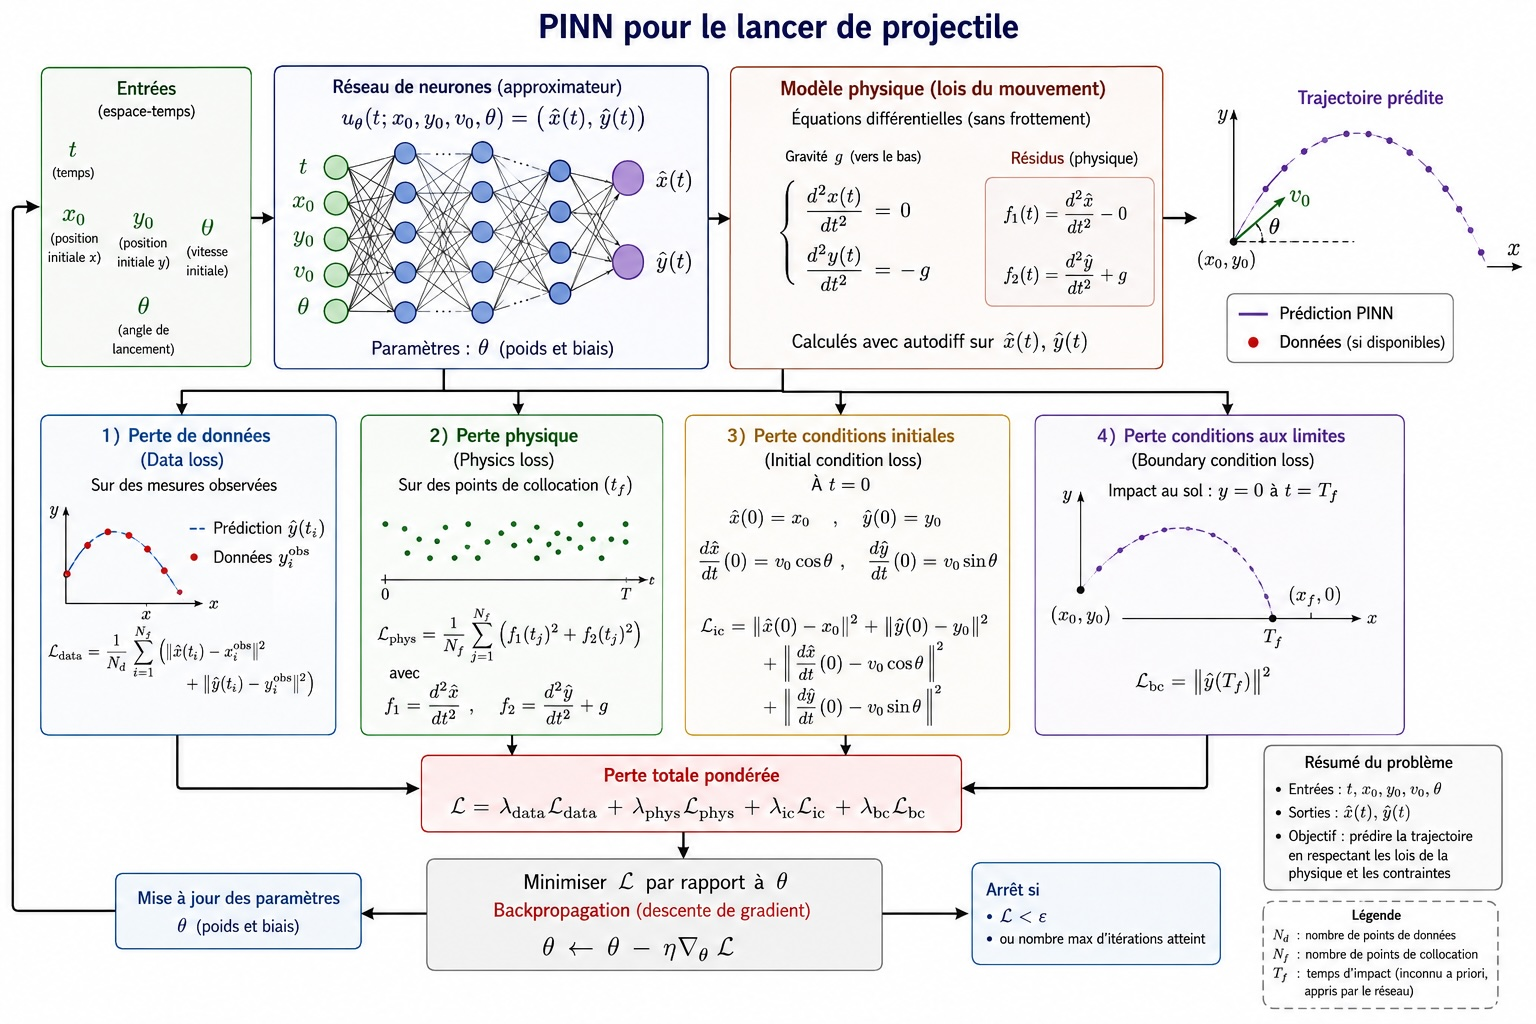

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math

# ==============================
# 1. Configuration
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# Paramètres physiques
g = 9.81

# Conditions initiales
x0 = 1.0
y0 = 2.0

teta = math.pi/3
v0 = 20 # m/s
vx0 = v0*math.cos(teta) 
vy0 = v0*math.sin(teta) 

# Temps de vol théorique pour y = 2
T_final = 2 * vy0 / g

print("Device :", device)
print("Temps de vol théorique :", T_final)

# ==============================
# 2. Helper pour les dérivées
# ==============================

def derivative(y, t):
    """
    Calcule dy/dt avec autograd.
    """
    return torch.autograd.grad(
        y,
        t,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]


model = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 2)  # sortie : [x(t), y(t)]
        ).to(device)

# ==============================
# 4. Points de collocation physique
# ==============================

N_f = 200

t_f = torch.linspace(0, T_final, N_f).view(-1, 1).to(device)
t_f.requires_grad_(True)

# ==============================
# 5. Condition initiale t = 0
# ==============================

t0 = torch.tensor([[0.0]], dtype=torch.float32).to(device)
t0.requires_grad_(True)

# ==============================
# 6. Données expérimentales simulées
# ==============================

N_data = 10
noise_level = 0.9

t_data = torch.linspace(0, T_final, N_data).view(-1, 1).to(device)

# Solution théorique aux temps expérimentaux
x_data_exact = x0 + vx0 * t_data
y_data_exact = y0 + vy0 * t_data - 0.5 * g * t_data ** 2

# Bruit gaussien
noise_x = noise_level * torch.randn_like(x_data_exact)
noise_y = noise_level * torch.randn_like(y_data_exact)

# Données expérimentales bruitées
x_data_exp = x_data_exact + noise_x
y_data_exp = y_data_exact + noise_y

# Regrouper en un tenseur de shape : [N_data, 2]
data_exp = torch.cat([x_data_exp, y_data_exp], dim=1)

# ==============================
# 7. Optimiseur
# ==============================

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Poids des différentes losses
lambda_physics = 1
lambda_ic = 1
lambda_data = 1

# ==============================
# 8. Entraînement
# ==============================

epochs = 8000

for epoch in range(epochs):

    model.train()

    # --------------------------
    # Loss physique
    # --------------------------

    pred_f = model(t_f)

    x_pred = pred_f[:, 0:1]
    y_pred = pred_f[:, 1:2]

    # Dérivées premières
    x_t = derivative(x_pred, t_f)
    y_t = derivative(y_pred, t_f)

    # Dérivées secondes
    x_tt = derivative(x_t, t_f)
    y_tt = derivative(y_t, t_f)

    # Equations physiques :
    # x''(t) = 0
    # y''(t) = -g  => y''(t) + g = 0
    residual_x = x_tt
    residual_y = y_tt + g

    loss_physics = torch.mean(residual_x ** 2) + torch.mean(residual_y ** 2)

    # --------------------------
    # Loss conditions initiales
    # --------------------------

    pred0 = model(t0)

    x0_pred = pred0[:, 0:1]
    y0_pred = pred0[:, 1:2]

    x0_t = derivative(x0_pred, t0)
    y0_t = derivative(y0_pred, t0)

    loss_ic_position = (x0_pred - x0) ** 2 + (y0_pred - y0) ** 2
    loss_ic_velocity = (x0_t - vx0) ** 2 + (y0_t - vy0) ** 2

    loss_ic = torch.mean(loss_ic_position + loss_ic_velocity)

    # --------------------------
    # Loss données expérimentales
    # --------------------------

    pred_data = model(t_data)

    loss_data = torch.mean((pred_data - data_exp) ** 2)

    # --------------------------
    # Loss totale
    # --------------------------

    loss = (
        lambda_physics * loss_physics
        + lambda_ic * loss_ic
        + lambda_data * loss_data
    )

    # --------------------------
    # Backpropagation
    # --------------------------

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.6f} | "
            f"Physics: {loss_physics.item():.6f} | "
            f"IC: {loss_ic.item():.6f} | "
            f"Data: {loss_data.item():.6f}"
        )


Device : cpu
Temps de vol théorique : 3.5311943069701877
Epoch [1000/8000] Loss: 31.518013 | Physics: 14.566320 | IC: 0.622562 | Data: 16.329132
Epoch [2000/8000] Loss: 1.042691 | Physics: 0.183440 | IC: 0.007451 | Data: 0.851800
Epoch [3000/8000] Loss: 0.751094 | Physics: 0.093869 | IC: 0.009682 | Data: 0.647542
Epoch [4000/8000] Loss: 0.665110 | Physics: 0.010347 | IC: 0.010318 | Data: 0.644445
Epoch [5000/8000] Loss: 0.668027 | Physics: 0.013278 | IC: 0.010373 | Data: 0.644377
Epoch [6000/8000] Loss: 0.670245 | Physics: 0.014093 | IC: 0.010653 | Data: 0.645499
Epoch [7000/8000] Loss: 0.663178 | Physics: 0.007753 | IC: 0.010313 | Data: 0.645111
Epoch [8000/8000] Loss: 0.661756 | Physics: 0.006900 | IC: 0.010023 | Data: 0.644834


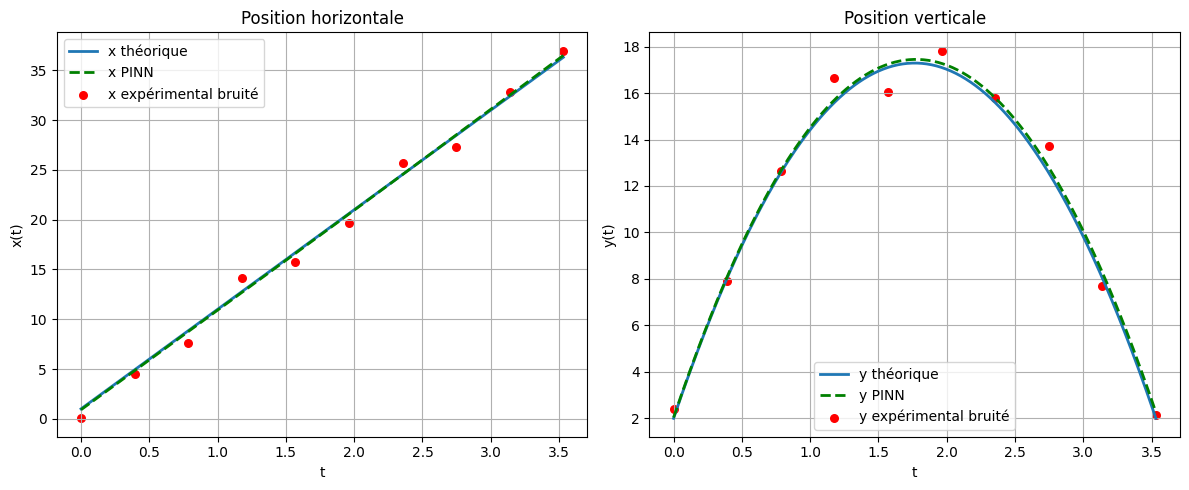

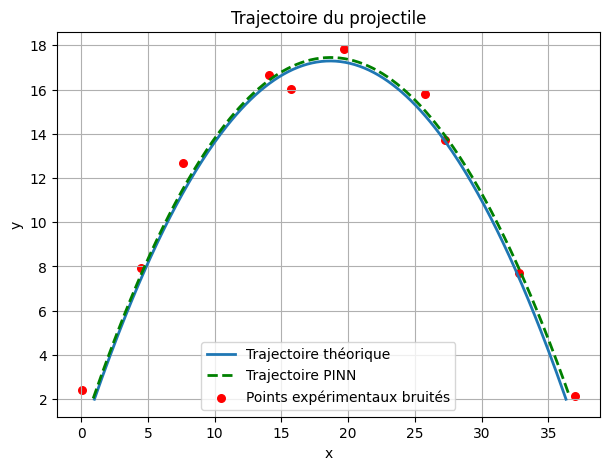

In [37]:
# ==============================
# 9. Évaluation
# ==============================

model.eval()

t_test = torch.linspace(0, T_final, 300).view(-1, 1).to(device)

with torch.no_grad():
    pred_test = model(t_test)

x_pinn = pred_test[:, 0:1]
y_pinn = pred_test[:, 1:2]

# Solution théorique exacte
x_exact = x0 + vx0 * t_test
y_exact = y0 + vy0 * t_test - 0.5 * g * t_test ** 2

# ==============================
# 10. Conversion CPU/Numpy
# ==============================

t_np = t_test.cpu().numpy()

x_pinn_np = x_pinn.cpu().numpy()
y_pinn_np = y_pinn.cpu().numpy()

x_exact_np = x_exact.cpu().numpy()
y_exact_np = y_exact.cpu().numpy()

t_data_np = t_data.cpu().numpy()
x_data_exp_np = x_data_exp.cpu().numpy()
y_data_exp_np = y_data_exp.cpu().numpy()

# ==============================
# 11. Visualisation x(t) et y(t)
# ==============================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_np, x_exact_np, label="x théorique", linewidth=2)
plt.plot(t_np, x_pinn_np, "--",color="green", label="x PINN", linewidth=2)
plt.scatter(
    t_data_np,
    x_data_exp_np,
    color="red",
    s=30,
    label="x expérimental bruité"
)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Position horizontale")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t_np, y_exact_np, label="y théorique", linewidth=2)
plt.plot(t_np, y_pinn_np, "--", color="green", label="y PINN", linewidth=2)
plt.scatter(
    t_data_np,
    y_data_exp_np,
    color="red",
    s=30,
    label="y expérimental bruité"
)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Position verticale")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ==============================
# 12. Visualisation trajectoire y(x)
# ==============================

plt.figure(figsize=(7, 5))

plt.plot(
    x_exact_np,
    y_exact_np,
    label="Trajectoire théorique",
    linewidth=2
)

plt.plot(
    x_pinn_np,
    y_pinn_np,
    "--", color="green",
    label="Trajectoire PINN",
    linewidth=2
)

plt.scatter(
    x_data_exp_np,
    y_data_exp_np,
    color="red",
    s=30,
    label="Points expérimentaux bruités"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectoire du projectile")
plt.legend()
plt.grid()
plt.show()

In [35]:
t_data

tensor([[0.0000],
        [0.3924],
        [0.7847],
        [1.1771],
        [1.5694],
        [1.9618],
        [2.3541],
        [2.7465],
        [3.1388],
        [3.5312]])

In [36]:
data_exp

tensor([[ 0.0488,  2.3954],
        [ 4.4880,  7.9184],
        [ 7.6540, 12.6630],
        [14.1065, 16.6683],
        [15.7570, 16.0307],
        [19.7154, 17.8220],
        [25.7322, 15.7916],
        [27.2776, 13.7168],
        [32.8069,  7.7049],
        [36.9753,  2.1562]])

In [34]:
import pandas as pd
pd.DataFrame(torch.cat((t_data,data_exp), dim=1), columns=["t_data","X","y"])

,time,X,y
0,0.000000,0.048762,2.395429
1,0.392355,4.488008,7.918429
2,0.784710,7.654029,12.662960
3,1.177065,14.106471,16.668299
4,1.569420,15.756966,16.030697
5,1.961775,19.715368,17.821987
6,2.354130,25.732170,15.791601
7,2.746484,27.277590,13.716774
8,3.138839,32.806938,7.704939
9,3.531194,36.975349,2.156162


Temps de vol théorique : 3.5311943069701877
Epoch [1000/8000] Loss: 5.292188 | 
Epoch [2000/8000] Loss: 0.374746 | 
Epoch [3000/8000] Loss: 0.074300 | 
Epoch [4000/8000] Loss: 0.024115 | 
Epoch [5000/8000] Loss: 0.008057 | 
Epoch [6000/8000] Loss: 0.001878 | 
Epoch [7000/8000] Loss: 0.000201 | 
Epoch [8000/8000] Loss: 0.000008 | 
torch.Size([10, 1]) torch.Size([10, 2])


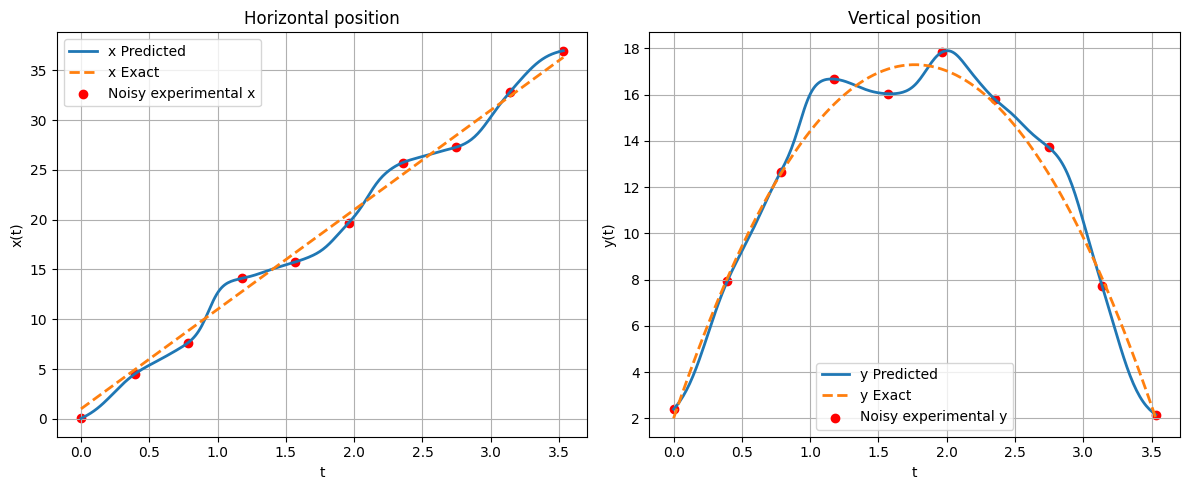

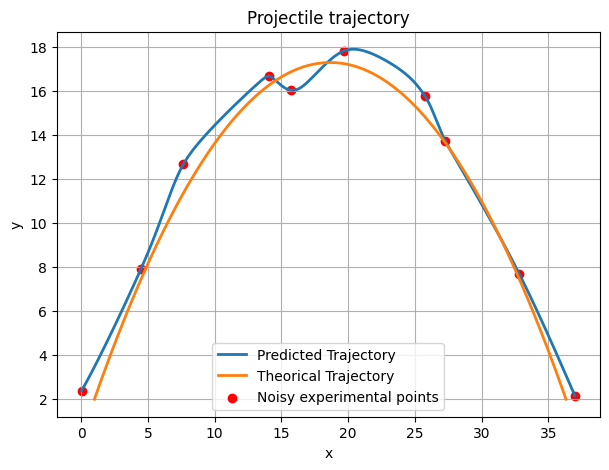

torch.Size([10, 1]) torch.Size([10, 2])


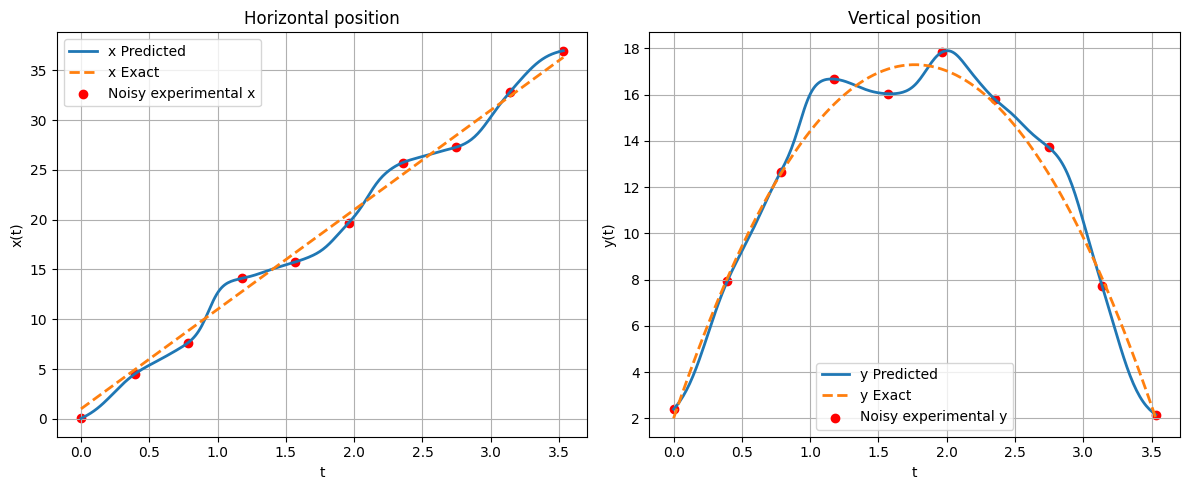

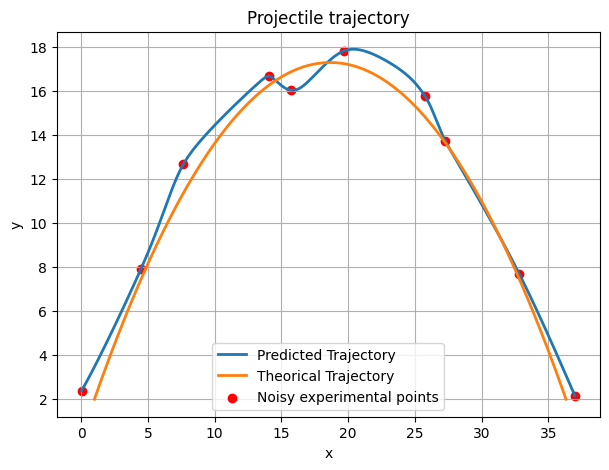

In [37]:
# Coefficient thermique
alpha = 0.1

# Domaine Omega
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

In [32]:
N_f = 5000

x_f = torch.rand(N_f, 1).to(device)
t_f = torch.rand(N_f, 1).to(device)

In [36]:
# ==============================
# 2. Solution exacte
# ==============================

def exact_solution(x, t):
    """
    Solution exacte de l'équation de la chaleur :
    u(x,t) = exp(-alpha*pi^2*t) * sin(pi*x)
    """
    return torch.exp(-alpha * torch.pi**2 * t) * torch.sin(torch.pi * x)

In [35]:
x_f.shape

torch.Size([5000, 1])

In [38]:
N_ic = 200

x_ic = torch.linspace(x_min, x_max, N_ic).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic).to(device)

u_ic = exact_solution(x_ic, t_ic)

In [42]:
u_ic.shape

torch.Size([200, 1])

## Exemple 3 : Equation de la chaleur

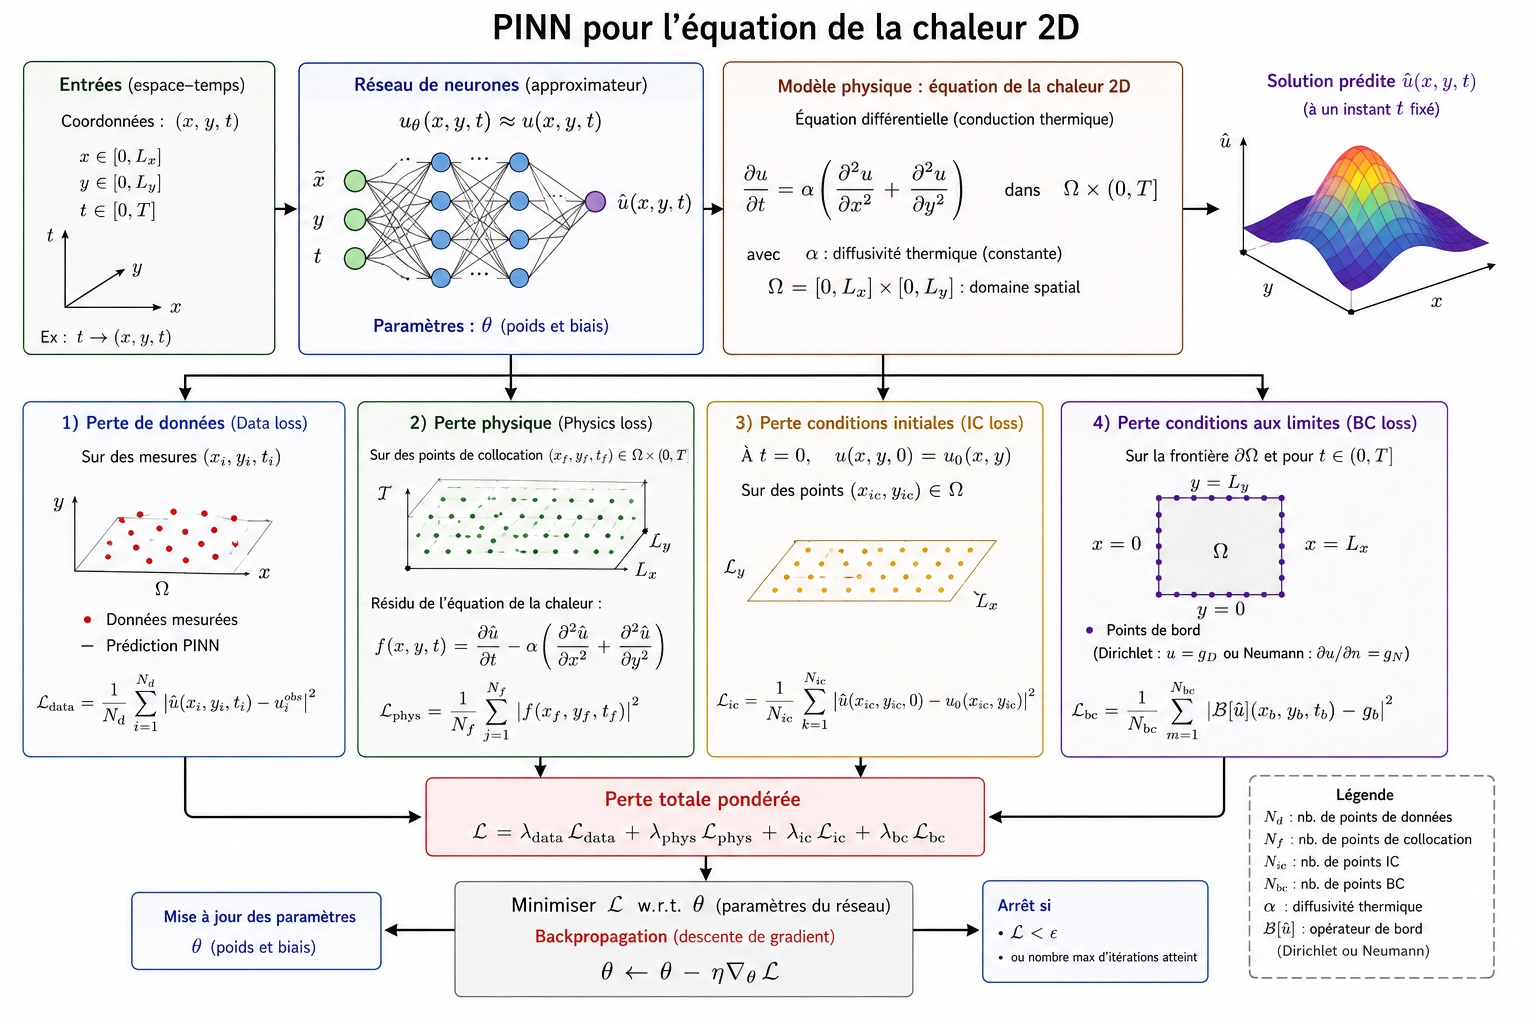

Device : cpu
Epoch [1000/10000] Loss: 3.993209e-03 | Physics: 3.792529e-04 | IC: 3.319709e-05 | BC: 2.799833e-05 | Data: 3.552761e-04
Epoch [2000/10000] Loss: 8.972609e-03 | Physics: 3.489209e-04 | IC: 5.870548e-04 | BC: 2.320394e-04 | Data: 7.804594e-04
Epoch [3000/10000] Loss: 3.642916e-03 | Physics: 1.095233e-04 | IC: 1.305691e-05 | BC: 9.909458e-06 | Data: 3.510426e-04
Epoch [4000/10000] Loss: 3.594049e-03 | Physics: 7.867986e-05 | IC: 1.134888e-05 | BC: 1.033137e-05 | Data: 3.493688e-04
Epoch [5000/10000] Loss: 3.682739e-03 | Physics: 1.004656e-04 | IC: 1.684303e-05 | BC: 3.138723e-05 | Data: 3.534043e-04
Epoch [6000/10000] Loss: 3.558331e-03 | Physics: 6.007827e-05 | IC: 1.060557e-05 | BC: 1.141709e-05 | Data: 3.476230e-04
Epoch [7000/10000] Loss: 3.540548e-03 | Physics: 4.745429e-05 | IC: 1.047832e-05 | BC: 1.236065e-05 | Data: 3.470255e-04
Epoch [8000/10000] Loss: 3.530568e-03 | Physics: 4.057382e-05 | IC: 1.057743e-05 | BC: 1.318857e-05 | Data: 3.466228e-04
Epoch [9000/10000] 

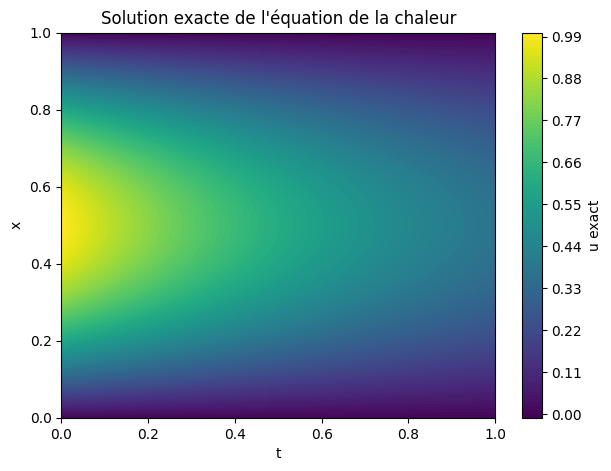

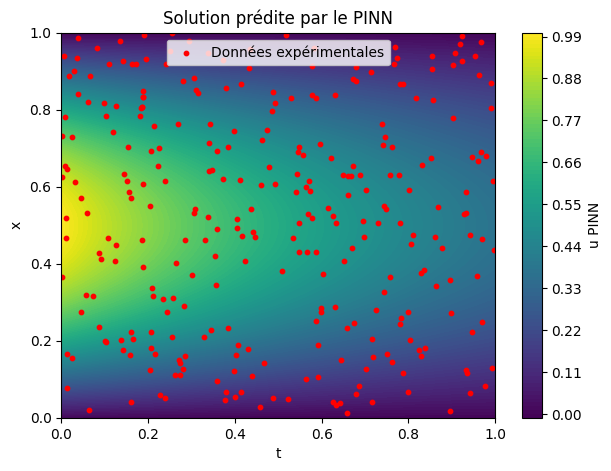

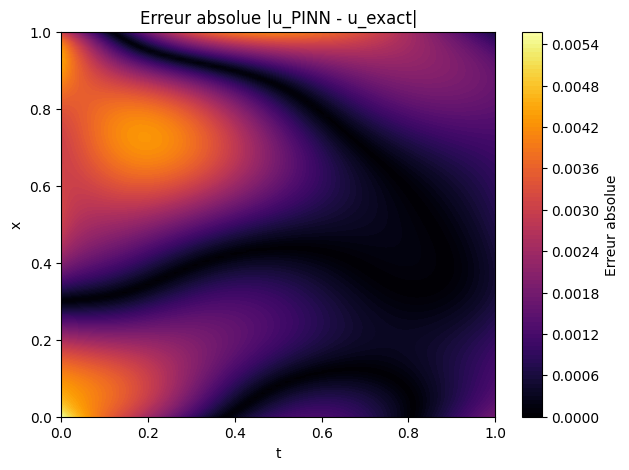

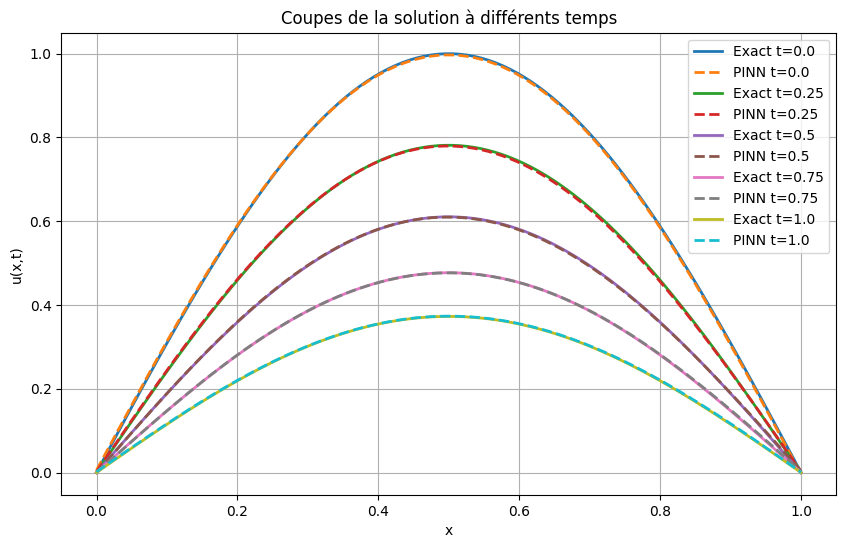

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ==============================
# 1. Configuration
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# Coefficient thermique
alpha = 0.1

# Domaine Omega
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

print("Device :", device)

# ==============================
# 2. Solution exacte
# ==============================

def exact_solution(x, t):
    """
    Solution exacte de l'équation de la chaleur :
    u(x,t) = exp(-alpha*pi^2*t) * sin(pi*x)
    """
    return torch.exp(-alpha * torch.pi**2 * t) * torch.sin(torch.pi * x)

# ==============================
# 3. Helper pour les dérivées
# ==============================

def derivative(y, x):
    """
    Calcule dy/dx avec autograd.
    """
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

# ==============================
# 4. Réseau PINN
# ==============================

class HeatPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),   # entrée : [x, t]
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)    # sortie : u(x,t)
        )

    def forward(self, x, t):
        """
        x shape : [N, 1]
        t shape : [N, 1]
        """
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)


model = HeatPINN().to(device)

# ==============================
# 5. Points de collocation physique
# ==============================

N_f = 5000

x_f = torch.rand(N_f, 1).to(device)
t_f = torch.rand(N_f, 1).to(device)

x_f.requires_grad_(True)
t_f.requires_grad_(True)

# ==============================
# 6. Conditions initiales u(x,0)
# ==============================

N_ic = 200

x_ic = torch.linspace(x_min, x_max, N_ic).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic).to(device)

u_ic = exact_solution(x_ic, t_ic)

# ==============================
# 7. Conditions aux bords u(0,t)=0 et u(1,t)=0
# ==============================

N_bc = 200

t_bc = torch.linspace(t_min, t_max, N_bc).view(-1, 1).to(device)

x_bc_left = torch.zeros_like(t_bc).to(device)
x_bc_right = torch.ones_like(t_bc).to(device)

u_bc_left = torch.zeros_like(t_bc).to(device)
u_bc_right = torch.zeros_like(t_bc).to(device)

# ==============================
# 8. Données expérimentales bruitées
# ==============================

N_data = 300
noise_level = 0.02

# Points expérimentaux aléatoires dans le domaine
x_data = torch.rand(N_data, 1).to(device)
t_data = torch.rand(N_data, 1).to(device)

# Solution exacte aux points expérimentaux
u_data_exact = exact_solution(x_data, t_data)

# Ajout du bruit
noise = noise_level * torch.randn_like(u_data_exact)
u_data_exp = u_data_exact + noise

# ==============================
# 9. Optimiseur
# ==============================

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Poids des losses
lambda_physics = 1.0
lambda_ic = 1.0
lambda_bc = 1.0
lambda_data = 10.0

# ==============================
# 10. Entraînement
# ==============================

epochs = 10000

for epoch in range(epochs):

    model.train()

    # --------------------------
    # Loss physique
    # --------------------------

    u_f = model(x_f, t_f)

    u_t = derivative(u_f, t_f)
    u_x = derivative(u_f, x_f)
    u_xx = derivative(u_x, x_f)

    # Equation de la chaleur :
    # u_t = alpha * u_xx
    # donc résidu : u_t - alpha*u_xx = 0
    residual = u_t - alpha * u_xx

    loss_physics = torch.mean(residual ** 2)

    # --------------------------
    # Loss condition initiale
    # --------------------------

    u_ic_pred = model(x_ic, t_ic)

    loss_ic = torch.mean((u_ic_pred - u_ic) ** 2)

    # --------------------------
    # Loss conditions aux bords
    # --------------------------

    u_left_pred = model(x_bc_left, t_bc)
    u_right_pred = model(x_bc_right, t_bc)

    loss_bc_left = torch.mean((u_left_pred - u_bc_left) ** 2)
    loss_bc_right = torch.mean((u_right_pred - u_bc_right) ** 2)

    loss_bc = loss_bc_left + loss_bc_right

    # --------------------------
    # Loss données expérimentales
    # --------------------------

    u_data_pred = model(x_data, t_data)

    loss_data = torch.mean((u_data_pred - u_data_exp) ** 2)

    # --------------------------
    # Loss totale
    # --------------------------

    loss = (
        lambda_physics * loss_physics
        + lambda_ic * loss_ic
        + lambda_bc * loss_bc
        + lambda_data * loss_data
    )

    # --------------------------
    # Backpropagation
    # --------------------------

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.6e} | "
            f"Physics: {loss_physics.item():.6e} | "
            f"IC: {loss_ic.item():.6e} | "
            f"BC: {loss_bc.item():.6e} | "
            f"Data: {loss_data.item():.6e}"
        )

# ==============================
# 11. Évaluation sur une grille
# ==============================

model.eval()

N_x = 100
N_t = 100

x_grid = torch.linspace(x_min, x_max, N_x).to(device)
t_grid = torch.linspace(t_min, t_max, N_t).to(device)

X, T = torch.meshgrid(x_grid, t_grid, indexing="ij")

x_test = X.reshape(-1, 1)
t_test = T.reshape(-1, 1)

with torch.no_grad():
    u_pred = model(x_test, t_test)
    u_exact = exact_solution(x_test, t_test)

u_pred_grid = u_pred.reshape(N_x, N_t)
u_exact_grid = u_exact.reshape(N_x, N_t)

error_grid = torch.abs(u_pred_grid - u_exact_grid)

# Conversion numpy
X_np = X.cpu().numpy()
T_np = T.cpu().numpy()

u_pred_np = u_pred_grid.cpu().numpy()
u_exact_np = u_exact_grid.cpu().numpy()
error_np = error_grid.cpu().numpy()

x_data_np = x_data.cpu().numpy()
t_data_np = t_data.cpu().numpy()
u_data_exp_np = u_data_exp.cpu().numpy()

# ==============================
# 12. Visualisation solution exacte
# ==============================

plt.figure(figsize=(7, 5))
plt.contourf(T_np, X_np, u_exact_np, levels=100, cmap="viridis")
plt.colorbar(label="u exact")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Solution exacte de l'équation de la chaleur")
plt.show()

# ==============================
# 13. Visualisation solution PINN
# ==============================

plt.figure(figsize=(7, 5))
plt.contourf(T_np, X_np, u_pred_np, levels=100, cmap="viridis")
plt.colorbar(label="u PINN")
plt.scatter(t_data_np, x_data_np, color="red", s=10, label="Données expérimentales")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Solution prédite par le PINN")
plt.legend()
plt.show()

# ==============================
# 14. Visualisation erreur
# ==============================

plt.figure(figsize=(7, 5))
plt.contourf(T_np, X_np, error_np, levels=100, cmap="inferno")
plt.colorbar(label="Erreur absolue")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Erreur absolue |u_PINN - u_exact|")
plt.show()

# ==============================
# 15. Coupes temporelles
# ==============================

times_to_plot = [0.0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(10, 6))

for time_value in times_to_plot:
    t_slice = torch.full((N_x, 1), time_value).to(device)
    x_slice = torch.linspace(x_min, x_max, N_x).view(-1, 1).to(device)

    with torch.no_grad():
        u_slice_pred = model(x_slice, t_slice)
        u_slice_exact = exact_solution(x_slice, t_slice)

    plt.plot(
        x_slice.cpu().numpy(),
        u_slice_exact.cpu().numpy(),
        linewidth=2,
        label=f"Exact t={time_value}"
    )

    plt.plot(
        x_slice.cpu().numpy(),
        u_slice_pred.cpu().numpy(),
        "--",
        linewidth=2,
        label=f"PINN t={time_value}"
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Coupes de la solution à différents temps")
plt.legend()
plt.grid()
plt.show()

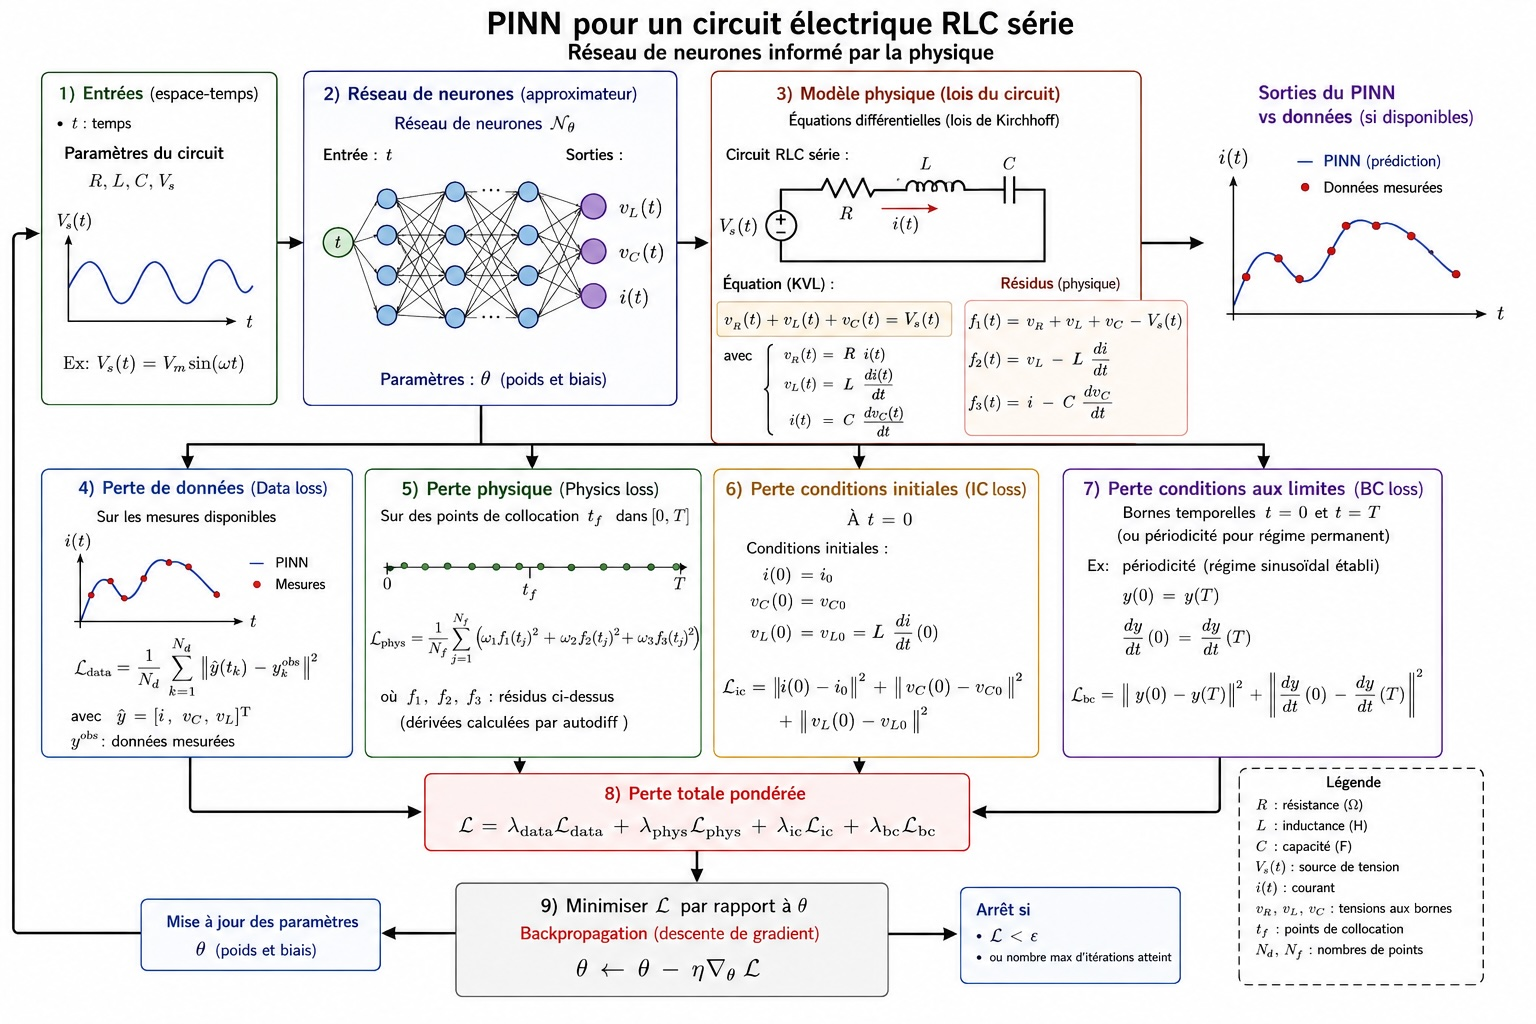

Device : cpu
Epoch     0 | Loss = 63.958733 | Data = 14.009298 | Physics = 49.470005 | IC = 0.046642 | BC = 0.013015
Epoch   500 | Loss = 16.511839 | Data = 3.956269 | Physics = 11.974231 | IC = 0.007312 | BC = 0.508221
Epoch  1000 | Loss = 5.486833 | Data = 1.281152 | Physics = 3.699850 | IC = 0.003912 | BC = 0.466706
Epoch  1500 | Loss = 5.241968 | Data = 1.155869 | Physics = 3.598794 | IC = 0.003999 | BC = 0.447312
Epoch  2000 | Loss = 5.164100 | Data = 1.137649 | Physics = 3.562561 | IC = 0.003544 | BC = 0.428446
Epoch  2500 | Loss = 5.122009 | Data = 1.147076 | Physics = 3.529729 | IC = 0.003294 | BC = 0.412262
Epoch  3000 | Loss = 5.059274 | Data = 1.122836 | Physics = 3.506063 | IC = 0.003308 | BC = 0.397292
Epoch  3500 | Loss = 5.010068 | Data = 1.120412 | Physics = 3.479501 | IC = 0.003138 | BC = 0.378775
Epoch  4000 | Loss = 4.960697 | Data = 1.141138 | Physics = 3.434571 | IC = 0.002962 | BC = 0.355371
Epoch  4500 | Loss = 4.885066 | Data = 1.159707 | Physics = 3.357423 | IC

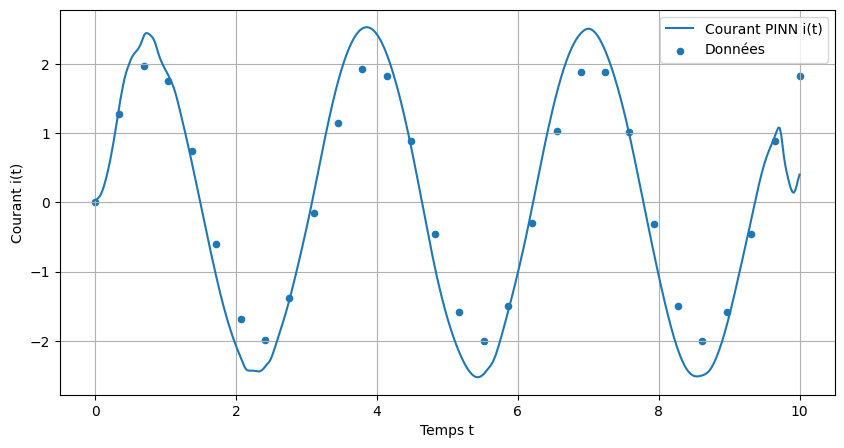

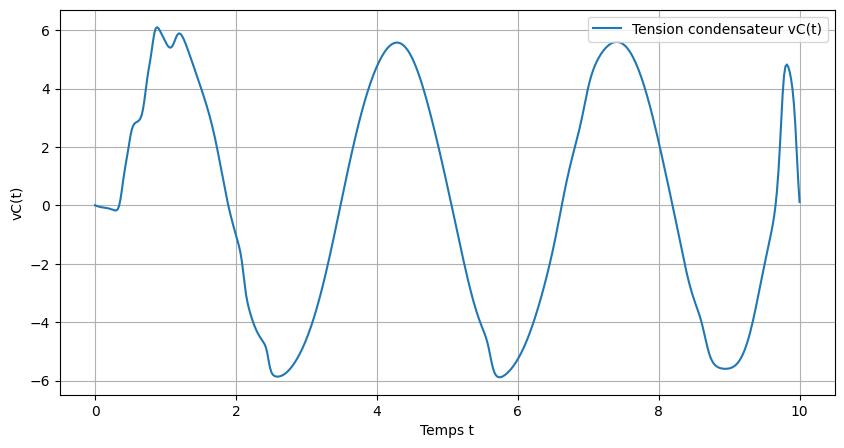

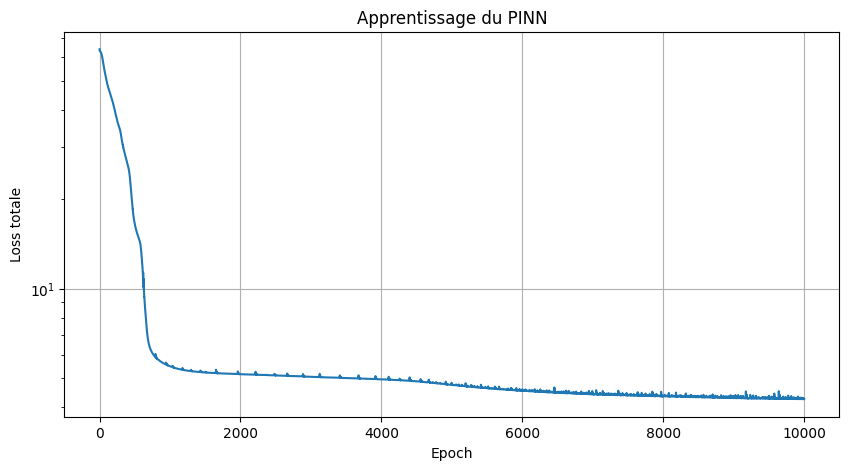

In [133]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Paramètres du circuit RLC
# ============================================================

R = 2.0       # Ohm
L = 0.5       # Henry
C = 0.1       # Farad

Vm = 10.0     # amplitude de la source
omega = 2.0   # pulsation rad/s

T = 10.0      # durée de simulation

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", device)


# ============================================================
# 2. Source de tension Vs(t)
# ============================================================

def Vs(t):
    return Vm * torch.sin(omega * t)


# ============================================================
# 3. Réseau de neurones
#
# Entrée :
#       t
#
# Sorties :
#       i(t)
#       vC(t)
# ============================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 2)
        )

    def forward(self, t):

        output = self.net(t)

        i = output[:, 0:1]
        vC = output[:, 1:2]

        return i, vC


model = PINN().to(device)


# ============================================================
# 4. Points de collocation pour la physique
# ============================================================

Nf = 2000

t_f = torch.rand(Nf, 1, device=device) * T

t_f.requires_grad_(True)


# ============================================================
# 5. Quelques données expérimentales simulées
# ============================================================

Nd = 30

t_data = torch.linspace(0, T, Nd).reshape(-1, 1).to(device)


# ------------------------------------------------------------
# Pour l'exemple, on crée des données synthétiques.
# Dans une vraie application, remplacer par vos mesures.
# ------------------------------------------------------------

i_data = 2 * torch.sin(omega * t_data)

vC_data = 5 * torch.sin(omega * t_data - 0.8)


# ============================================================
# 6. Conditions initiales
# ============================================================

i0 = 0.0
vC0 = 0.0

t0 = torch.tensor([[0.0]], device=device)


# ============================================================
# 7. Loss DATA
# ============================================================

def data_loss():

    i_pred, vC_pred = model(t_data)

    loss_i = torch.mean(
        (i_pred - i_data) ** 2
    )

    loss_vc = torch.mean(
        (vC_pred - vC_data) ** 2
    )

    return loss_i + loss_vc


# ============================================================
# 8. Loss PHYSIQUE
# ============================================================
#
# Loi de Kirchhoff :
#
#       vR + vL + vC = Vs
#
# avec
#
#       vR = R i
#       vL = L di/dt
#
# donc
#
#       R i + L di/dt + vC - Vs = 0
#
#
# Relation du condensateur :
#
#       i = C dvC/dt
#
# donc
#
#       i - C dvC/dt = 0
#
# ============================================================

def physics_loss():

    i, vC = model(t_f)

    # dérivée di/dt
    di_dt = torch.autograd.grad(
        i,
        t_f,
        grad_outputs=torch.ones_like(i),
        create_graph=True
    )[0]

    # dérivée dvC/dt
    dvC_dt = torch.autograd.grad(
        vC,
        t_f,
        grad_outputs=torch.ones_like(vC),
        create_graph=True
    )[0]

    # --------------------------------------------------------
    # Résidu 1 : loi des mailles
    # --------------------------------------------------------

    f1 = (
        R * i
        + L * di_dt
        + vC
        - Vs(t_f)
    )

    # --------------------------------------------------------
    # Résidu 2 : loi du condensateur
    # --------------------------------------------------------

    f2 = (
        i
        - C * dvC_dt
    )

    loss_f1 = torch.mean(f1 ** 2)

    loss_f2 = torch.mean(f2 ** 2)

    return loss_f1 + loss_f2


# ============================================================
# 9. Loss CONDITIONS INITIALES
# ============================================================

def initial_condition_loss():

    i_pred, vC_pred = model(t0)

    loss_i0 = (i_pred - i0) ** 2

    loss_vc0 = (vC_pred - vC0) ** 2

    return torch.mean(loss_i0 + loss_vc0)


# ============================================================
# 10. Loss CONDITION AUX LIMITES
# ============================================================
#
# Exemple :
#
# régime périodique
#
#       i(0) = i(T)
#       vC(0) = vC(T)
#
# ============================================================

def boundary_condition_loss():

    t_start = torch.tensor(
        [[0.0]],
        device=device,
        requires_grad=True
    )

    t_end = torch.tensor(
        [[T]],
        device=device,
        requires_grad=True
    )

    i_start, vC_start = model(t_start)

    i_end, vC_end = model(t_end)

    loss_i = torch.mean(
        (i_start - i_end) ** 2
    )

    loss_vc = torch.mean(
        (vC_start - vC_end) ** 2
    )

    return loss_i + loss_vc


# ============================================================
# 11. Pondération des différentes Loss
# ============================================================

lambda_data = 1.0
lambda_phys = 1.0
lambda_ic = 10.0
lambda_bc = 1.0


# ============================================================
# 12. Optimiseur
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# ============================================================
# 13. Entraînement
# ============================================================

epochs = 10000

history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    # --------------------------------------------------------
    # Calcul des quatre losses
    # --------------------------------------------------------

    L_data = data_loss()

    L_phys = physics_loss()

    L_ic = initial_condition_loss()

    L_bc = boundary_condition_loss()

    # --------------------------------------------------------
    # Loss totale
    # --------------------------------------------------------

    loss = (
        lambda_data * L_data
        + lambda_phys * L_phys
        + lambda_ic * L_ic
        + lambda_bc * L_bc
    )

    # ========================================================
    # BACKPROPAGATION
    # ========================================================

    loss.backward()

    # ========================================================
    # MISE A JOUR DES PARAMETRES theta
    # ========================================================

    optimizer.step()

    history.append(loss.item())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.item():.6f} | "
            f"Data = {L_data.item():.6f} | "
            f"Physics = {L_phys.item():.6f} | "
            f"IC = {L_ic.item():.6f} | "
            f"BC = {L_bc.item():.6f}"
        )


# ============================================================
# 14. Prédiction
# ============================================================

t_test = torch.linspace(
    0,
    T,
    500
).reshape(-1, 1).to(device)

with torch.no_grad():

    i_pred, vC_pred = model(t_test)


t_np = t_test.cpu().numpy()

i_np = i_pred.cpu().numpy()

vC_np = vC_pred.cpu().numpy()


# ============================================================
# 15. Calcul de vL et vR
# ============================================================

t_test_grad = t_test.clone().detach().requires_grad_(True)

i_grad, vC_grad = model(t_test_grad)

di_dt = torch.autograd.grad(
    i_grad,
    t_test_grad,
    grad_outputs=torch.ones_like(i_grad),
    create_graph=False
)[0]


vR = R * i_grad

vL = L * di_dt


# ============================================================
# 16. Affichage
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t_np,
    i_np,
    label="Courant PINN i(t)"
)

plt.scatter(
    t_data.cpu(),
    i_data.cpu(),
    label="Données",
    s=20
)

plt.xlabel("Temps t")
plt.ylabel("Courant i(t)")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    t_np,
    vC_np,
    label="Tension condensateur vC(t)"
)

plt.xlabel("Temps t")
plt.ylabel("vC(t)")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 17. Evolution de la Loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.semilogy(history)

plt.xlabel("Epoch")
plt.ylabel("Loss totale")

plt.title("Apprentissage du PINN")

plt.grid()

plt.show()

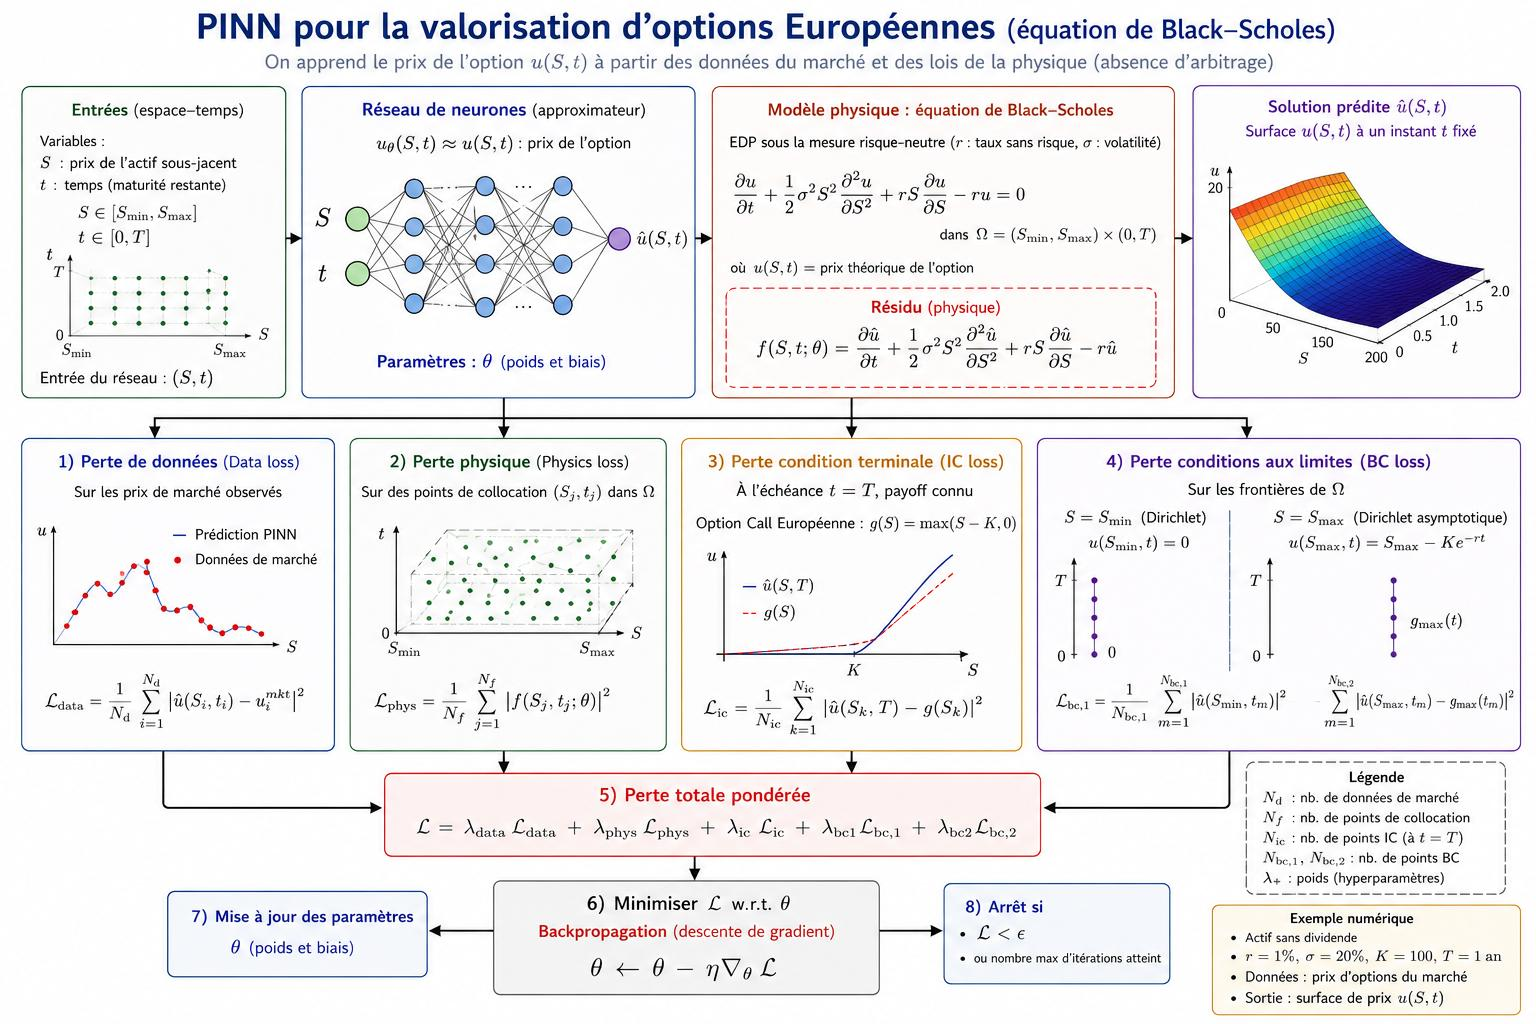

Device: cpu
Epoch     0 | Total = 2.742501e+04 | Data = 4.603072e+02 | Physics = 4.528456e-06 | Terminal = 1.685600e+03 | BC = 1.010870e+04
Epoch   500 | Total = 9.095686e+03 | Data = 1.830727e+01 | Physics = 1.430810e+01 | Terminal = 4.734020e+02 | BC = 4.329051e+03
Epoch  1000 | Total = 3.292121e+03 | Data = 1.137233e+00 | Physics = 8.327853e+00 | Terminal = 1.381980e+02 | BC = 1.900676e+03
Epoch  1500 | Total = 1.212179e+03 | Data = 1.257327e-01 | Physics = 1.800975e+01 | Terminal = 3.840414e+01 | BC = 8.100024e+02
Epoch  2000 | Total = 4.627626e+02 | Data = 5.095964e-02 | Physics = 2.696728e+01 | Terminal = 1.003897e+01 | BC = 3.353547e+02
Epoch  2500 | Total = 1.941322e+02 | Data = 7.442290e-02 | Physics = 2.781004e+01 | Terminal = 2.609465e+00 | BC = 1.401531e+02
Epoch  3000 | Total = 8.557933e+01 | Data = 6.341620e-02 | Physics = 1.163349e+01 | Terminal = 8.287242e-01 | BC = 6.559518e+01
Epoch  3500 | Total = 5.512564e+01 | Data = 2.170425e-02 | Physics = 8.398881e+00 | Terminal

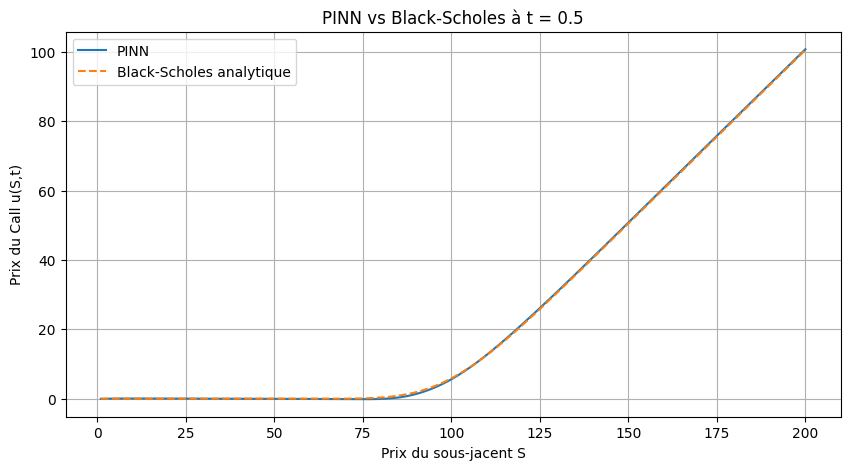

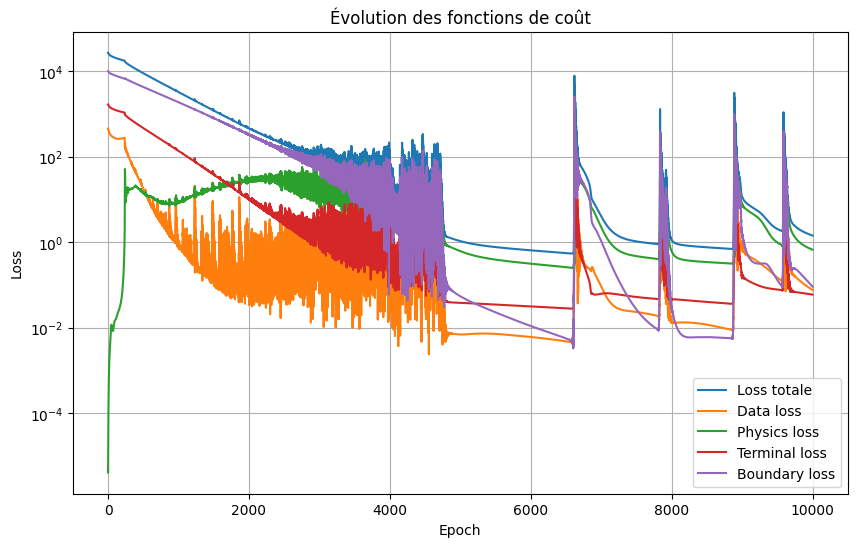

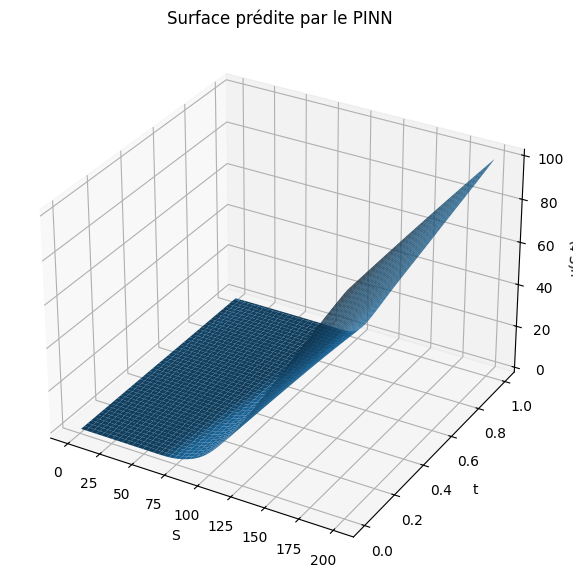

In [135]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Paramètres du problème
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

r = 0.01          # taux sans risque
sigma = 0.20      # volatilité
K = 100.0         # strike
T = 1.0           # maturité en années

S_min = 1e-3
S_max = 200.0

print("Device:", device)


# ============================================================
# 2. Réseau de neurones
#
# Entrées :
#   S : prix du sous-jacent
#   t : temps
#
# Sortie :
#   u(S,t) : prix de l'option
# ============================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, S, t):

        x = torch.cat([S, t], dim=1)

        return self.net(x)


model = PINN().to(device)


# ============================================================
# 3. Payoff d'un Call européen
# ============================================================

def payoff_call(S):

    return torch.maximum(
        S - K,
        torch.zeros_like(S)
    )


# ============================================================
# 4. Points de collocation pour la loss physique
# ============================================================

Nf = 5000

S_f = (
    S_min
    + (S_max - S_min)
    * torch.rand(Nf, 1, device=device)
)

t_f = T * torch.rand(Nf, 1, device=device)

S_f.requires_grad_(True)
t_f.requires_grad_(True)


# ============================================================
# 5. Données de marché synthétiques
#
# Pour une vraie application :
# remplacer ces données par des prix observés
# ============================================================

Nd = 50

S_data = torch.linspace(
    50,
    150,
    Nd
).reshape(-1, 1).to(device)

t_data = torch.full_like(
    S_data,
    0.5
)

# ------------------------------------------------------------
# Black-Scholes analytique utilisé ici seulement pour créer
# des données synthétiques.
# ------------------------------------------------------------

def normal_cdf(x):
    return 0.5 * (
        1.0 + torch.erf(x / np.sqrt(2.0))
    )


def black_scholes_call(S, t):

    tau = T - t

    tau = torch.clamp(tau, min=1e-6)

    d1 = (
        torch.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (
        sigma * torch.sqrt(tau)
    )

    d2 = d1 - sigma * torch.sqrt(tau)

    C = (
        S * normal_cdf(d1)
        -
        K * torch.exp(-r * tau)
        * normal_cdf(d2)
    )

    return C


u_data = black_scholes_call(
    S_data,
    t_data
).detach()


# ============================================================
# 6. LOSS DE DONNÉES
# ============================================================

def data_loss():

    u_pred = model(S_data, t_data)

    return torch.mean(
        (u_pred - u_data) ** 2
    )


# ============================================================
# 7. LOSS PHYSIQUE
#
# Équation de Black-Scholes :
#
# du/dt
# + 1/2 sigma² S² d²u/dS²
# + r S du/dS
# - r u = 0
#
# ============================================================

def physics_loss():

    u = model(S_f, t_f)

    # --------------------------------------------------------
    # du/dt
    # --------------------------------------------------------

    du_dt = torch.autograd.grad(
        u,
        t_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # --------------------------------------------------------
    # du/dS
    # --------------------------------------------------------

    du_dS = torch.autograd.grad(
        u,
        S_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # --------------------------------------------------------
    # d²u/dS²
    # --------------------------------------------------------

    d2u_dS2 = torch.autograd.grad(
        du_dS,
        S_f,
        grad_outputs=torch.ones_like(du_dS),
        create_graph=True
    )[0]

    # --------------------------------------------------------
    # Résidu Black-Scholes
    # --------------------------------------------------------

    residual = (
        du_dt
        + 0.5 * sigma**2
        * S_f**2
        * d2u_dS2
        + r * S_f * du_dS
        - r * u
    )

    return torch.mean(
        residual ** 2
    )


# ============================================================
# 8. LOSS CONDITION TERMINALE
#
# À t = T :
#
# u(S,T) = max(S-K,0)
#
# ============================================================

Nic = 200

S_terminal = torch.linspace(
    S_min,
    S_max,
    Nic
).reshape(-1, 1).to(device)

t_terminal = torch.full_like(
    S_terminal,
    T
)


def terminal_condition_loss():

    u_pred = model(
        S_terminal,
        t_terminal
    )

    u_target = payoff_call(
        S_terminal
    )

    return torch.mean(
        (u_pred - u_target) ** 2
    )


# ============================================================
# 9. LOSS CONDITIONS AUX LIMITES
#
# Pour un Call européen :
#
# S -> 0 :
#     u(0,t) = 0
#
# S -> grand :
#     u(S,t) ≈ S - K exp(-r(T-t))
#
# ============================================================

Nbc = 200

t_bc = torch.linspace(
    0,
    T,
    Nbc
).reshape(-1, 1).to(device)


def boundary_condition_loss():

    # --------------------------------------------------------
    # Bord gauche : S = S_min
    # --------------------------------------------------------

    S_left = torch.full_like(
        t_bc,
        S_min
    )

    u_left = model(
        S_left,
        t_bc
    )

    loss_left = torch.mean(
        u_left ** 2
    )

    # --------------------------------------------------------
    # Bord droit : S = S_max
    # --------------------------------------------------------

    S_right = torch.full_like(
        t_bc,
        S_max
    )

    u_right = model(
        S_right,
        t_bc
    )

    target_right = (
        S_right
        -
        K * torch.exp(
            -r * (T - t_bc)
        )
    )

    loss_right = torch.mean(
        (u_right - target_right) ** 2
    )

    return loss_left + loss_right


# ============================================================
# 10. Pondération des losses
# ============================================================

lambda_data = 1.0
lambda_phys = 1.0
lambda_ic = 10.0
lambda_bc = 1.0


# ============================================================
# 11. Optimiseur
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# ============================================================
# 12. Entraînement
# ============================================================

epochs = 10000

history_total = []
history_data = []
history_phys = []
history_ic = []
history_bc = []


for epoch in range(epochs):

    optimizer.zero_grad()

    # --------------------------------------------------------
    # Calcul des quatre losses
    # --------------------------------------------------------

    L_data = data_loss()

    L_phys = physics_loss()

    L_ic = terminal_condition_loss()

    L_bc = boundary_condition_loss()

    # --------------------------------------------------------
    # Loss totale
    # --------------------------------------------------------

    loss = (
        lambda_data * L_data
        +
        lambda_phys * L_phys
        +
        lambda_ic * L_ic
        +
        lambda_bc * L_bc
    )

    # ========================================================
    # BACKPROPAGATION
    # ========================================================

    loss.backward()

    # ========================================================
    # Mise à jour des paramètres theta
    # ========================================================

    optimizer.step()

    history_total.append(loss.item())
    history_data.append(L_data.item())
    history_phys.append(L_phys.item())
    history_ic.append(L_ic.item())
    history_bc.append(L_bc.item())

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {loss.item():.6e} | "
            f"Data = {L_data.item():.6e} | "
            f"Physics = {L_phys.item():.6e} | "
            f"Terminal = {L_ic.item():.6e} | "
            f"BC = {L_bc.item():.6e}"
        )


# ============================================================
# 13. Comparaison PINN / Black-Scholes
# ============================================================

S_test = torch.linspace(
    1,
    200,
    300
).reshape(-1, 1).to(device)

t_test = torch.full_like(
    S_test,
    0.5
)

with torch.no_grad():

    u_pinn = model(
        S_test,
        t_test
    )

    u_exact = black_scholes_call(
        S_test,
        t_test
    )


S_np = S_test.cpu().numpy()

u_pinn_np = u_pinn.cpu().numpy()

u_exact_np = u_exact.cpu().numpy()


# ============================================================
# 14. Affichage du prix de l'option
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    S_np,
    u_pinn_np,
    label="PINN"
)

plt.plot(
    S_np,
    u_exact_np,
    "--",
    label="Black-Scholes analytique"
)

plt.xlabel("Prix du sous-jacent S")
plt.ylabel("Prix du Call u(S,t)")

plt.title(
    "PINN vs Black-Scholes à t = 0.5"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 15. Courbes des différentes losses
# ============================================================

plt.figure(figsize=(10, 6))

plt.semilogy(
    history_total,
    label="Loss totale"
)

plt.semilogy(
    history_data,
    label="Data loss"
)

plt.semilogy(
    history_phys,
    label="Physics loss"
)

plt.semilogy(
    history_ic,
    label="Terminal loss"
)

plt.semilogy(
    history_bc,
    label="Boundary loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Évolution des fonctions de coût"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 16. Surface u(S,t)
# ============================================================

S_vals = torch.linspace(
    1,
    200,
    100
).to(device)

t_vals = torch.linspace(
    0,
    T,
    100
).to(device)

S_grid, t_grid = torch.meshgrid(
    S_vals,
    t_vals,
    indexing="ij"
)

S_input = S_grid.reshape(-1, 1)
t_input = t_grid.reshape(-1, 1)

with torch.no_grad():

    u_grid = model(
        S_input,
        t_input
    )

u_grid = u_grid.reshape(
    S_grid.shape
).cpu().numpy()

S_grid_np = S_grid.cpu().numpy()
t_grid_np = t_grid.cpu().numpy()


fig = plt.figure(
    figsize=(10, 7)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    S_grid_np,
    t_grid_np,
    u_grid
)

ax.set_xlabel("S")
ax.set_ylabel("t")
ax.set_zlabel("u(S,t)")

ax.set_title(
    "Surface prédite par le PINN"
)

plt.show()

## Simulations Lance projectile

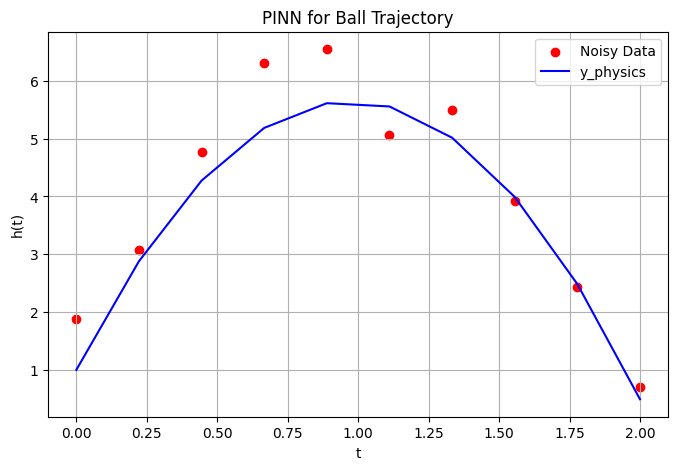

Train Model without pinns
Epoch 1000/8000, Total Loss = 0.115756, 
Epoch 2000/8000, Total Loss = 0.082335, 
Epoch 3000/8000, Total Loss = 0.053126, 
Epoch 4000/8000, Total Loss = 0.025763, 
Epoch 5000/8000, Total Loss = 0.001693, 
Epoch 6000/8000, Total Loss = 0.000000, 
Epoch 7000/8000, Total Loss = 0.000000, 
Epoch 8000/8000, Total Loss = 0.000000, 
Train Model With Pinns
Epoch 1000/8000, Total Loss = 0.733354, 
Epoch 2000/8000, Total Loss = 0.576531, 
Epoch 3000/8000, Total Loss = 0.570177, 
Epoch 4000/8000, Total Loss = 0.562927, 
Epoch 5000/8000, Total Loss = 0.559165, 
Epoch 6000/8000, Total Loss = 0.558451, 
Epoch 7000/8000, Total Loss = 0.558104, 
Epoch 8000/8000, Total Loss = 0.557456, 


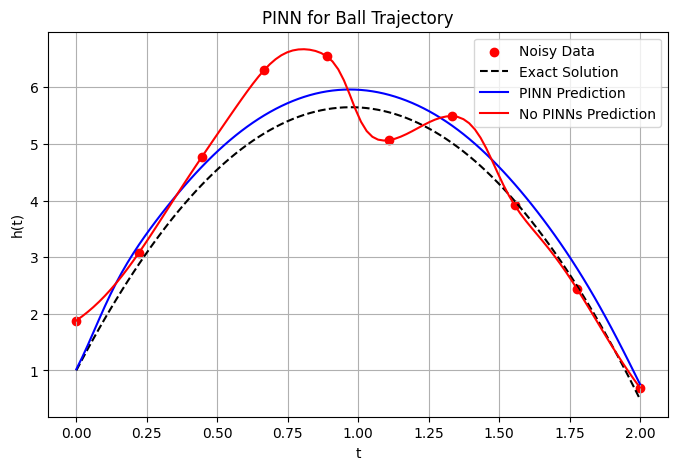

In [31]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sin, pi

# --------------------------
# 1. Generate Synthetic Data
# --------------------------

# Physics parameters
g = 9.8        # acceleration due to gravity
h0 = 1.0       # initial height
v0 = 13.5      # initial velocity
alpha = pi/4

# True (analytical) solution h(t) = h0 + v0*t - 0.5*g*t^2
def true_solution(t):
    return h0 + v0*sin(alpha)*t - 0.5*g*(t**2)

# Generate some time points
t_min, t_max = 0.0, 2.0
N_data = 10
t_data = np.linspace(t_min, t_max, N_data)

# Generate synthetic "experimental" heights with noise
np.random.seed(0)
noise_level = 0.5
h_data_exact = true_solution(t_data)
h_data_noisy = h_data_exact + noise_level*np.random.randn(N_data)

# Convert to PyTorch tensors
t_data_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1)
h_data_tensor = torch.tensor(h_data_noisy, dtype=torch.float32).view(-1, 1)

pd.DataFrame({"t":t_data, "h_Exp":h_data_noisy, "h_Physics": h_data_exact})
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(t_data, h_data_noisy, color='red', label='Noisy Data')
plt.plot(t_data, h_data_exact, color = 'blue', label = "y_physics")
plt.xlabel('t')
plt.ylabel('h(t)')
plt.legend()
plt.title('PINN for Ball Trajectory')
plt.grid(True)
plt.show()

# --------------------------------------------------------
# 2. Define a small feed-forward neural network for h(t)
# --------------------------------------------------------
class PINN(nn.Module):
    def __init__(self, n_hidden=20):
        super(PINN, self).__init__()
        # A simple MLP with 2 hidden layers
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 1)
        )

    def forward(self, t):
        """
        Forward pass: input shape (batch_size, 1) -> output shape (batch_size, 1)
        """
        return self.net(t)

# --------------------------------
# 3. Helper for Automatic Diff
# --------------------------------
def derivative(y, x):
    """
    Computes dy/dx using PyTorch's autograd.
    y and x must be tensors with requires_grad=True for x.
    """
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

# ----------------------------------------
# 4. Define the Loss Components (PINN)
# ----------------------------------------

# We have:
#    (1) Data loss (fit noisy data)
#    (2) ODE loss: dh/dt = v0 - g * t
#    (3) Initial condition loss: h(0) = h0

def physics_loss(model, t):
    """
    Compare d(h_pred)/dt with the known expression (v0 - g t).
    """
    # t must have requires_grad = True for autograd to work
    t.requires_grad_(True)

    h_pred = model(t)
    dh_dt_pred = derivative(h_pred, t)

    # For each t, physics says dh/dt = v0 - g * t
    dh_dt_true = v0 * sin(alpha) - g * t

    loss_ode = torch.mean((dh_dt_pred - dh_dt_true)**2)
    return loss_ode

def initial_condition_loss(model):
    """
    Enforce h(0) = h0.
    """
    # Evaluate at t=0
    t0 = torch.zeros(1, 1, dtype=torch.float32, requires_grad=False)
    h0_pred = model(t0)
    return (h0_pred - h0).pow(2).mean()

def data_loss(model, t_data, h_data):
    """
    MSE between predicted h(t_i) and noisy measurements h_data.
    """
    h_pred = model(t_data)
    return torch.mean((h_pred - h_data)**2)

# Hyperparameters for weighting the loss terms
lambda_data = 2.0
lambda_ode  = 20.0
lambda_ic   = 8.0

# For logging
num_epochs = 8000
print_every = 1000

def train (model, with_pinn=True):
    # 5. Training Setup
    # ---------------------------------------
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    # ---------------------------------------
    # 6. Training Loop
    # ---------------------------------------
    # ---------------------------------------
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        # Compute losses
        l_data = data_loss(model, t_data_tensor, h_data_tensor)
        if with_pinn == True:
            l_ode  = physics_loss(model, t_data_tensor)
            l_ic   = initial_condition_loss(model)
            # Combined loss
            loss = lambda_data * l_data + lambda_ode * l_ode + lambda_ic * l_ic
        else :
            loss =   l_data  

        
        # Backprop
        loss.backward()
        optimizer.step()

        # Print progress
        if (epoch+1) % print_every == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, "
                f"Total Loss = {loss.item():.6f}, ")

# Instantiate models
model_no_pinns = PINN(n_hidden=30)
model_pinns = PINN(n_hidden=30)

print("="*60)
print("Train Model without pinns")
print("="*60)
train(model_no_pinns, with_pinn=False)
print("="*60)
print("Train Model With Pinns")
print("="*60)
train(model_pinns, with_pinn=True)

# ---------------------------------------
# 7. Evaluate the Trained Model
# ---------------------------------------
model_pinns.eval()
model_no_pinns.eval()
t_plot = np.linspace(t_min, t_max, 100).reshape(-1, 1).astype(np.float32)
t_plot_tensor = torch.tensor(t_plot, requires_grad=True)
h_pred_no_pinns_plot = model_no_pinns(t_plot_tensor).detach().numpy()
h_pred_pinns_plot = model_pinns(t_plot_tensor).detach().numpy()

# True solution (for comparison)
h_true_plot = true_solution(t_plot)

# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(t_data, h_data_noisy, color='red', label='Noisy Data')
plt.plot(t_plot, h_true_plot, 'k--', label='Exact Solution')
plt.plot(t_plot, h_pred_pinns_plot, 'b', label='PINN Prediction')
plt.plot(t_plot, h_pred_no_pinns_plot, 'r', label='No PINNs Prediction')
plt.xlabel('t')
plt.ylabel('h(t)')
plt.legend()
plt.title('PINN for Ball Trajectory')
plt.grid(True)
plt.show()

